In [2]:
#!pip install lbforaging

## Foraging

**LB-Foraging** es un entorno *multi-agente* de recolección en cuadrícula con dos modos de juego.

### Espacio de acciones (por agente)

| Acción | Descripción |
|--------|-------------|
| NONE   | No hacer nada |
| NORTH  | Moverse al norte |
| SOUTH  | Moverse al sur |
| WEST   | Moverse al oeste |
| EAST   | Moverse al este |
| LOAD   | Recoger ítem adyacente |

### Observación (por agente)
Cada agente recibe un vector de 9 floats con posición y nivel de los agentes y del ítem visible.

### Recompensas
Un ítem se recoge cuando la suma de niveles de los agentes adyacentes que ejecutan **LOAD** ≥ nivel del ítem.
La recompensa se distribuye entre los participantes. El episodio termina cuando se recoge el ítem o se alcanza el límite de pasos.

### Modos de juego

| Config | `force_coop` | Descripción |
|--------|:---:|---|
| `Foraging-8x8-2p-1f-v3` | ✗ | **Modo mixto**: el nivel del ítem es aleatorio; ~42 % de episodios requieren cooperación y ~58 % son competitivos. |
| `Foraging-8x8-2p-1f-coop-v3` | ✓ | **Modo cooperativo**: la cooperación es **obligatoria** en todos los episodios. |

### Diferencia con juegos matriciales

> A diferencia de MP y RPS, Foraging es un juego **secuencial con estado**. No existe un equilibrio de Nash
> analítico expresable como una distribución sobre acciones, por lo que **no se analiza convergencia de política
> al NE**. En su lugar se reportan métricas de aprendizaje por refuerzo: **recompensa acumulada**, **tasa de éxito**
> y **pasos por episodio**. La línea de referencia Nash en la tasa de éxito es la tasa óptima estimada
> empíricamente, no un NE de estrategia mixta.

In [3]:
import lbforaging
from games.foraging import Foraging
import numpy as np
import time
import matplotlib.pyplot as plt
import os

from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM
from agents.random_agent import RandomAgent
from utils.constants import COLORS, JAL_AM_PALETTE

## Configuración de Experimentos

Se definen 4 configuraciones con distinto tamaño de grilla, número de jugadores y horizonte de entrenamiento.
Cada entrada incluye los hiperparámetros del agente y el `train_config` (iteraciones × episodios por iteración).

In [4]:
def epsilon_decay(max_t, min_eps=0.01):
    """Decay rate so ε reaches min_eps after max_t steps."""
    return min_eps ** (1 / max_t)

configurations = {
    '0': {
        'game':         "Foraging-5x5-2p-1f-v3",
        'iql':          {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(25_000),    'seed': 1},
        'jalam':        {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(25_000),    'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 10},
    },
    '1': {
        'game':         "Foraging-8x8-2p-1f-v3",
        'iql':          {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(250_000),   'seed': 1},
        'jalam':        {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(250_000),   'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 50},
    },
    '2': {
        'game':         "Foraging-8x8-3p-1f-v3",
        'iql':          {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(500_000),   'seed': 1},
        'jalam':        {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(500_000),   'seed': 1},
        'train_config': {'episodes': 100, 'iterations': 100},
    },
    '3': {
        'game':         "Foraging-8x8-3p-1f-coop-v3",
        'iql':          {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(1_500_000), 'seed': 1},
        'jalam':        {'alpha': 0.1, 'epsilon_min': 0.01, 'epsilon_decay': epsilon_decay(1_500_000), 'seed': 1},
        'train_config': {'episodes': 1000, 'iterations': 100},
    },
}

os.makedirs('figures/Foraging', exist_ok=True)

## Funciones de Entrenamiento

Tomadas de IQL.ipynb: `play_episode` incluye `reset()` por episodio y la actualización terminal del paso final,
`run` acumula recompensas, y `train` itera imprimiendo progreso cada 10 iteraciones.

In [5]:
def play_episode(game, agents, verbose=False, render=False):
    game.reset()
    step_count = 0
    for agent in game.agents:
        if hasattr(agents[agent], 'reset'):
            agents[agent].reset()
    if verbose:
        print(f"Step: {step_count}")
        for agent in game.agents:
            print(f"Agent {agent} observe: {game.observe(agent)}")
    cum_rewards = {agent: 0.0 for agent in game.agents}
    if render:
        game.render()
        time.sleep(0.5)
    while not game.done():
        step_count += 1
        actions = {agent: agents[agent].action() for agent in game.agents}
        game.step(actions)
        for agent in game.agents:
            cum_rewards[agent] += game.reward(agent)
        if verbose:
            print(f"Step: {step_count}")
            for agent in game.agents:
                print(f"  {agent} action: {actions[agent]} - {game.action_set[actions[agent]]}")
                print(f"  {agent} reward: {game.reward(agent)}")
                print(f"  {agent} observe: {game.observe(agent)}")
        if render:
            game.render()
            time.sleep(0.5)
    for agent in game.agents:
        agents[agent].update()
    return cum_rewards


def run(game, agents, episodes=1, verbose=False, render=False):
    sum_rewards = {agent: 0.0 for agent in game.agents}
    total_steps = 0
    success_count = 0
    for _ in range(episodes):
        cum_rewards = play_episode(game, agents, verbose=verbose, render=render)
        for agent in game.agents:
            sum_rewards[agent] += cum_rewards[agent]
        total_steps += game.current_step
        if any(v > 0 for v in cum_rewards.values()):
            success_count += 1
    return sum_rewards, total_steps, success_count

def parse_foraging_observation(obs, n_players):
    obs = list(obs)

    food_y, food_x, food_level = obs[:3]

    players = {}
    offset = 3

    for i in range(n_players):
        y, x, level = obs[offset:offset + 3]
        players[f"P{i}"] = {
            "position": (int(y), int(x)),
            "level": int(level),
        }
        offset += 3

    return {
        "food": {
            "position": (int(food_y), int(food_x)),
            "level": int(food_level),
        },
        "players": players,
    }

def print_foraging_initial_state(game, header="Estado inicial del episodio"):
    """Imprime posición y nivel de la comida y de cada jugador tras un reset."""
    parsed_obs = parse_foraging_observation(
        game.observe(game.agents[0]),
        n_players=len(game.agents),
    )
    food = parsed_obs["food"]
    print('===========================================')
    print(header)
    print(f"  Comida: posición={food['position']}, nivel={food['level']}")
    for player_id, player_info in parsed_obs["players"].items():
        print(
            f"  {player_id}: posición={player_info['position']}, "
            f"nivel={player_info['level']}"
        )
    print('===========================================\n')

def train(game, agents, train_config, progress=False, verbose=False, render=False):
    iterations      = train_config['iterations']
    episodes        = train_config['episodes']
    average_rewards = {agent: [] for agent in game.agents}
    success_rates   = []
    avg_steps       = []

    if progress:
        game.reset()
        for agent in game.agents:
            if hasattr(agents[agent], 'reset'):
                agents[agent].reset()
        print(f"Entrenamiento: {iterations} iteraciones × {episodes} episodios")
        print_foraging_initial_state(game)

    for i in range(1, iterations + 1):
        sum_rewards, total_steps, success_count = run(game, agents, episodes=episodes)
        for agent in game.agents:
            average_rewards[agent].append(sum_rewards[agent] / episodes)
        success_rates.append(success_count / episodes)
        avg_steps.append(total_steps / episodes)
        if progress and (i % 10 == 0):
            print(f"Iteración {i} ({i * episodes} episodios)")
            for agent in game.agents:
                print(f"  {agent}: {average_rewards[agent][-1]:.4f}")
    if progress:
        print(f"\nFinal — {iterations} iters × {episodes} eps = {iterations * episodes} total episodes")
        for agent in game.agents:
            print(f"  {agent}: {average_rewards[agent][-1]:.4f}")
    return average_rewards, success_rates, avg_steps


def plot_training(average_rewards, title, colors=None, save_path=None, success_rates=None, avg_steps=None):
    """Recompensa promedio, tasa de éxito y pasos por episodio durante el entrenamiento."""
    default_colors = ['#FF9800', '#FF5722', '#FFC107', '#795548']
    n_plots = 1 + (1 if success_rates is not None else 0) + (1 if avg_steps is not None else 0)
    fig, axes = plt.subplots(1, n_plots, figsize=(8 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]
    ax = axes[0]
    for i, (agent, rewards) in enumerate(average_rewards.items()):
        color = colors[i] if colors and i < len(colors) else default_colors[i % len(default_colors)]
        ax.plot(rewards, label=agent, color=color)
    ax.set_xlabel('Iteración')
    ax.set_ylabel('Recompensa promedio / episodio')
    ax.set_title(title)
    ax.legend()
    plot_idx = 1
    if success_rates is not None:
        ax = axes[plot_idx]
        ax.plot(success_rates, color='#4CAF50')
        ax.set_xlabel('Iteración')
        ax.set_ylabel('Tasa de éxito')
        ax.set_title('Tasa de éxito en recolección')
        ax.set_ylim(0, 1)
        plot_idx += 1
    if avg_steps is not None:
        ax = axes[plot_idx]
        ax.plot(avg_steps, color='#2196F3')
        ax.set_xlabel('Iteración')
        ax.set_ylabel('Pasos promedio')
        ax.set_title('Cantidad de pasos requeridos para completar el episodio')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


## Funciones de Visualización

In [6]:
def render_board(ax, field, players, grid_size,
                 step=None, actions=None, rewards=None, action_set=None):
    PLAYER_COLORS = ['#1565C0', '#B71C1C', '#1B5E20']
    FOOD_COLOR    = '#2E7D32'
    EMPTY_COLOR   = '#ECEFF1'
    ax.set_facecolor(EMPTY_COLOR)
    for r in range(grid_size):
        for c in range(grid_size):
            color = '#E3E8EE' if (r + c) % 2 == 0 else EMPTY_COLOR
            ax.add_patch(plt.Rectangle((c - 0.5, r - 0.5), 1, 1, color=color, zorder=0))
    food_cells = list(zip(*field.nonzero())) if field.any() else []
    for r, c in food_cells:
        ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
                                    color=FOOD_COLOR, zorder=2, linewidth=1.5, edgecolor='#1B5E20'))
        ax.text(c, r, 'F\nlv' + str(int(field[r, c])),
                ha='center', va='center', fontsize=6, fontweight='bold', color='white', zorder=3)
    for i, (pr, pc, plevel) in enumerate(players):
        color = PLAYER_COLORS[i % len(PLAYER_COLORS)]
        ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,
                                    color=color, zorder=2, linewidth=1.5, edgecolor='black'))
        act_lbl = ''
        if actions is not None and action_set is not None:
            key = 'agent_' + str(i)
            if key in actions:
                act_lbl = '\n' + action_set[actions[key]][:3]
        ax.text(pc, pr, 'P' + str(i) + act_lbl,
                ha='center', va='center', fontsize=7, color='white', fontweight='bold', zorder=3)
    ax.set_xlim(-0.5, grid_size - 0.5)
    ax.set_ylim(grid_size - 0.5, -0.5)
    ax.set_aspect('equal')
    ax.set_xticks(range(grid_size))
    ax.set_yticks(range(grid_size))
    ax.tick_params(labelsize=5, length=0)
    got_reward = rewards and any(v > 0 for v in rewards.values())
    title = ('Step ' + str(step)) if step is not None else 'Inicio'
    if got_reward:
        title += ' ✓'
    ax.set_title(title, fontsize=8, pad=2, color='#2E7D32' if got_reward else 'black')


def run_episode_visual(game, agents, max_display=None, title='', seed=None, save_path=None):
    game.reset(seed=seed)
    env = game.env.unwrapped
    grid_size = env.field.shape[0]
    frames = []

    def snap(step, actions=None, rewards=None):
        frames.append({
            'step':    step,
            'actions': dict(actions) if actions else None,
            'rewards': dict(rewards) if rewards else None,
            'field':   env.field.copy(),
            'players': [(p.position[0], p.position[1], p.level) for p in env.players],
        })

    snap(0)
    cum_rewards = {a: 0.0 for a in game.agents}
    while not game.done():
        actions  = {a: agents[a].action() for a in game.agents}
        game.step(actions)
        step_rew = {a: game.reward(a) for a in game.agents}
        for a in game.agents:
            cum_rewards[a] += step_rew[a]
        snap(game.current_step, actions, step_rew)
    if max_display is not None and len(frames) > max_display:
        idx = list(np.linspace(0, len(frames) - 1, max_display, dtype=int))
        frames = [frames[i] for i in sorted(set(idx))]
    n    = len(frames)
    cols = min(n, 6)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.9, rows * 2.3))
    axes_flat = np.array(axes).flatten() if n > 1 else np.array([axes])
    for ax, fr in zip(axes_flat, frames):
        render_board(ax, fr['field'], fr['players'], grid_size,
                      step=fr['step'], actions=fr['actions'],
                      rewards=fr['rewards'], action_set=game.action_set)
    for ax in axes_flat[len(frames):]:
        ax.set_visible(False)
    legend_parts = [f'P{i} ({a}): {round(cum_rewards[a], 2)}' for i, a in enumerate(game.agents)]
    legend = '  |  '.join(legend_parts) + f'  |  {game.current_step} pasos total'
    if title:
        legend = title + '\n' + legend
    plt.suptitle(legend, fontsize=9, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    return cum_rewards, game.current_step


def show_trained_game(game, agents, label, max_tries=30, save_path=None):
    """Visualiza un episodio con agentes pre-entrenados (ε=0). Busca la primera seed exitosa."""
    found_seed = None
    for seed in range(1, max_tries + 1):
        for ag in agents.values():
            if hasattr(ag, 'reset'):
                ag.reset()
        game.reset(seed=seed)
        cum = {a: 0.0 for a in game.agents}
        while not game.done():
            acts = {a: agents[a].action() for a in game.agents}
            game.step(acts)
            for a in game.agents:
                cum[a] += game.reward(a)
        if sum(cum.values()) > 0:
            found_seed = seed
            break
    use_seed = found_seed if found_seed is not None else 1
    suffix   = '' if found_seed else ' — sin éxito'
    for ag in agents.values():
        if hasattr(ag, 'reset'):
            ag.reset()
    run_episode_visual(game, agents, max_display=None, title=label + suffix, seed=use_seed, save_path=save_path)

## Exploración del Entorno

Se ejecuta un episodio completo con agentes aleatorios mostrando el tablero en cada step.
Cada celda muestra la posición de los jugadores **P0** (azul) y **P1** (rojo),
la comida **F** (verde) con su nivel, y la acción tomada en ese step.
El título del step se marca con ✓ cuando se recoge comida.

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


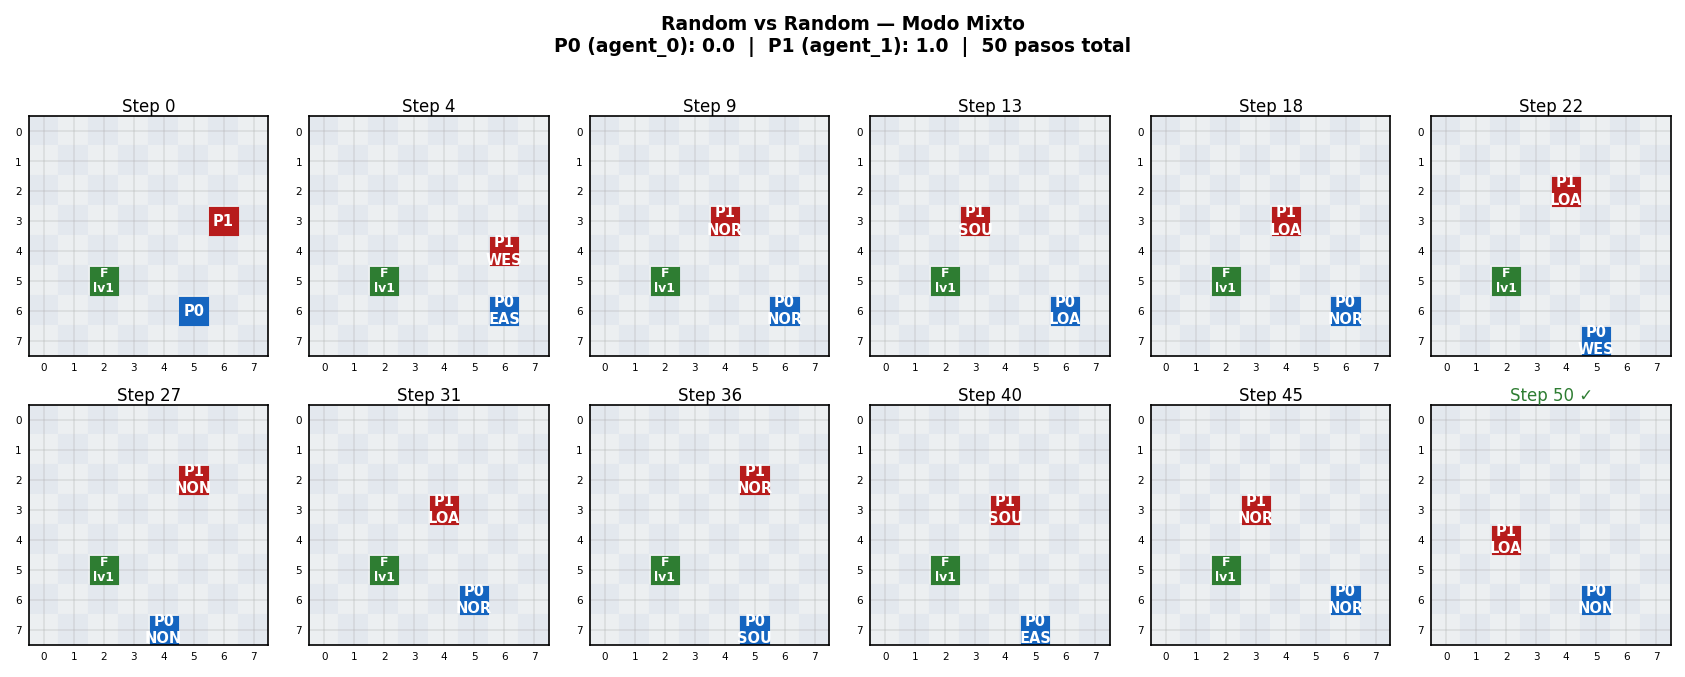

({'agent_0': 0.0, 'agent_1': 1.0}, 50)

In [32]:
# Modo Mixto
_g_exp = Foraging(config=None, seed=42)
_agents_exp = {a: RandomAgent(game=_g_exp, agent=a) for a in _g_exp.agents}
run_episode_visual(_g_exp, _agents_exp, max_display=12,
                    title='Random vs Random — Modo Mixto')

## Experimentos: IQL, JAL-AM y equipos mixtos

Para cada una de las 4 configuraciones se entrena **IQL** y **JAL-AM** en self-play.
En las configuraciones 3-player (configs 2 y 3) se añaden experimentos mixtos:
- JAL-AM × 2 + IQL × 1
- IQL × 2 + JAL-AM × 1

### Configuración 0 — `Foraging-5x5-2p-1f-v3`

Grilla 5×5, 2 jugadores, 1 ítem. Horizonte corto: 10 iteraciones × 100 episodios = 1 000 episodios totales.

=== IQL — Foraging-5x5-2p-1f-v3 ===
Entrenamiento: 10 iteraciones × 100 episodios
Estado inicial del episodio
  Comida: posición=(3, 1), nivel=2
  P0: posición=(2, 3), nivel=2
  P1: posición=(0, 0), nivel=2

Iteración 10 (1000 episodios)
  agent_0: 0.7400
  agent_1: 0.2100

Final — 10 iters × 100 eps = 1000 total episodes
  agent_0: 0.7400
  agent_1: 0.2100


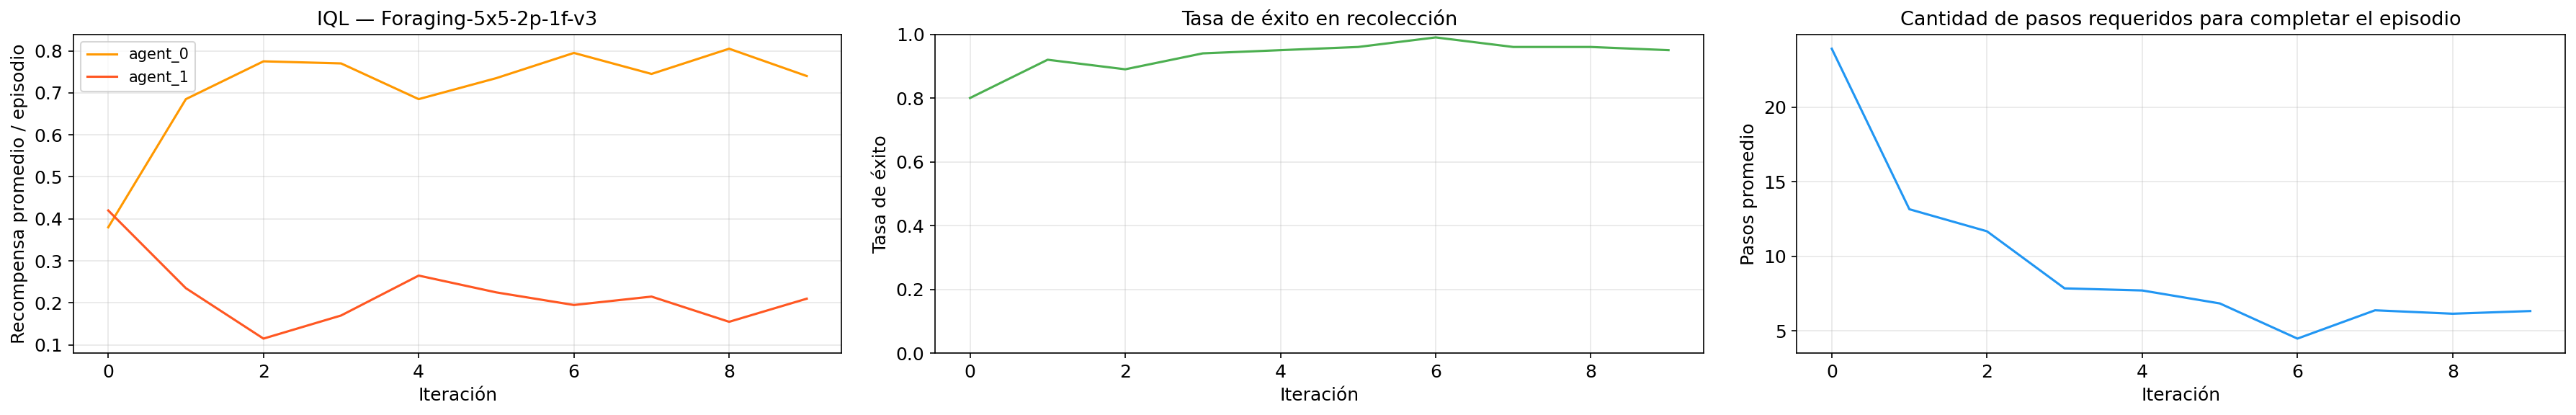

In [33]:
# ── IQL — Config 0: Foraging-5x5-2p-1f-v3 ────────────────────────────────────
config = configurations['0']
game_iql_0 = Foraging(config=config['game'], seed=1)
agents_iql_0 = {a: IndependentQLearning(game=game_iql_0, agent=a, **config['iql'])
                for a in game_iql_0.agents}

print(f"=== IQL — {config['game']} ===")
avg_iql_0, success_iql_0, steps_iql_0 = train(game_iql_0, agents_iql_0, config['train_config'], progress=True)

plot_training(avg_iql_0,
              title=f"IQL — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722'],
              save_path='figures/Foraging/iql_config0_training.png',
              success_rates=success_iql_0, avg_steps=steps_iql_0)

for a in game_iql_0.agents:
    agents_iql_0[a].epsilon = 0.0
    agents_iql_0[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


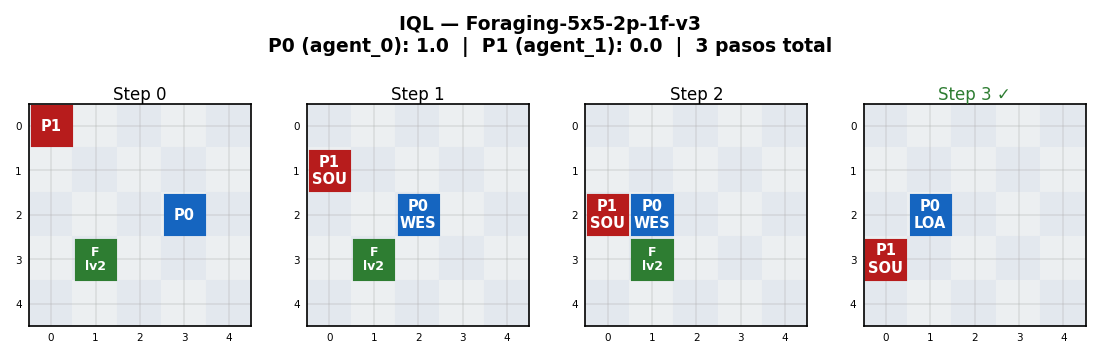

In [34]:
show_trained_game(game_iql_0, agents_iql_0, f'IQL — {configurations["0"]["game"]}', save_path='figures/Foraging/iql_config0_game.png')

#### Observaciones
En este experimento puede observarse un comportamiento bastante desbalanceado entre ambos agentes utilizando Independent Q-Learning en el ambiente `Foraging-5x5-2p-1f-v3`.

Durante las primeras iteraciones ambos agentes comienzan con recompensas relativamente similares, pero rápidamente el agente `agent_0` incrementa significativamente su recompensa promedio por episodio, estabilizándose alrededor de valores cercanos a $0.75 - 0.8$. En cambio, el agente `agent_1` reduce progresivamente su recompensa y permanece en valores considerablemente menores.

Esto sugiere que uno de los agentes logra aprender una política más efectiva para alcanzar o recolectar el recurso disponible, mientras que el otro agente queda parcialmente “dominado” o desplazado durante el entrenamiento.

Además, el comportamiento observado resulta consistente con una de las limitaciones principales de Independent Q-Learning en ambientes multiagente: cada agente aprende de manera independiente asumiendo un entorno estacionario, aunque en realidad las políticas de los demás agentes cambian continuamente. Esto puede generar dinámicas inestables o estrategias donde un agente termina explotando mejor el ambiente que el otro.

También puede observarse que las recompensas parecen estabilizarse relativamente rápido, lo cual tiene sentido considerando que el ambiente utilizado es pequeño, contiene únicamente un recurso y posee una cantidad reducida de agentes.

En conjunto, los resultados muestran que IQL logra aprender comportamientos útiles en Foraging, aunque no necesariamente conduce a soluciones balanceadas o coordinadas entre los agentes.

=== JAL-AM — Foraging-5x5-2p-1f-v3 ===
Entrenamiento: 10 iteraciones × 100 episodios
Estado inicial del episodio
  Comida: posición=(3, 1), nivel=2
  P0: posición=(2, 3), nivel=2
  P1: posición=(0, 0), nivel=2

Iteración 10 (1000 episodios)
  agent_0: 0.7083
  agent_1: 0.2617

Final — 10 iters × 100 eps = 1000 total episodes
  agent_0: 0.7083
  agent_1: 0.2617


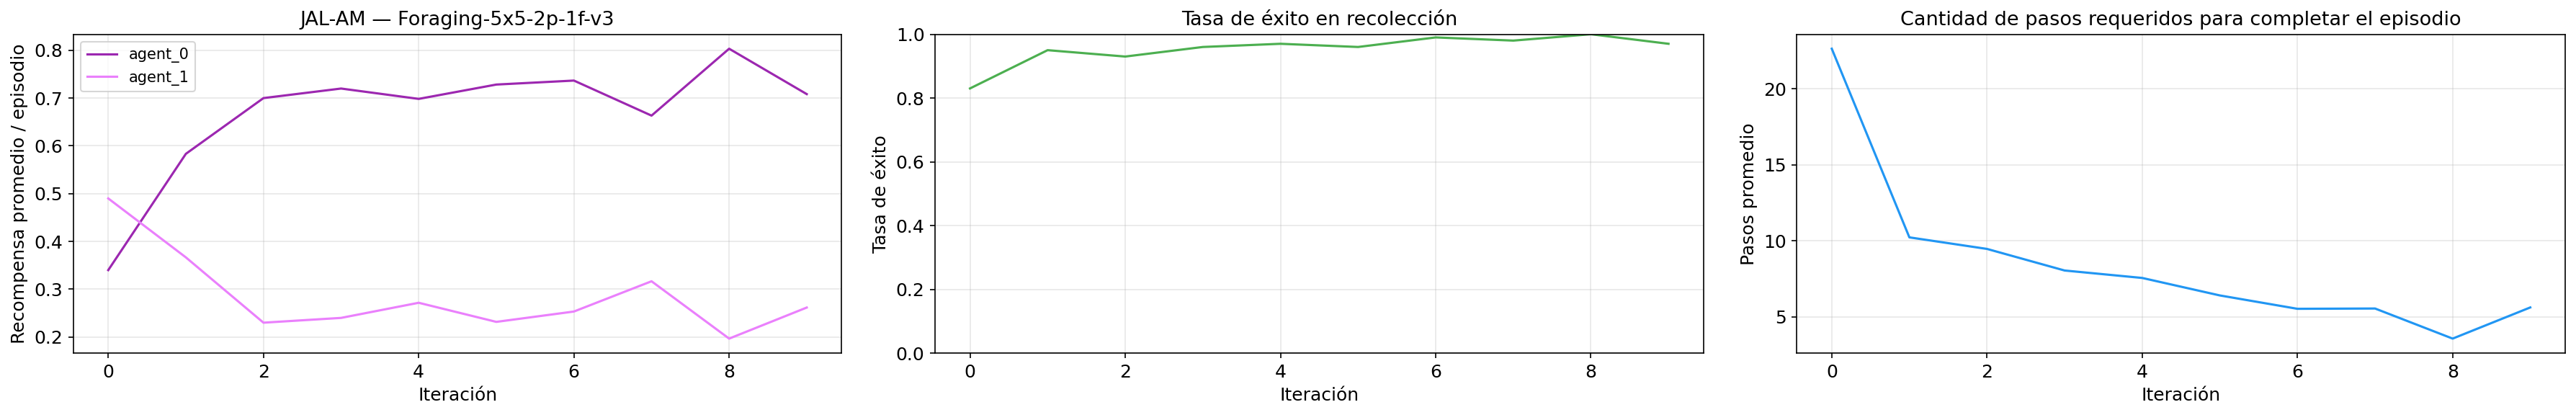

In [35]:
# ── JAL-AM — Config 0: Foraging-5x5-2p-1f-v3 ─────────────────────────────────
config = configurations['0']
game_jalam_0 = Foraging(config=config['game'], seed=1)
agents_jalam_0 = {a: JointActionLearningAM(game=game_jalam_0, agent=a, **config['jalam'])
                  for a in game_jalam_0.agents}

print(f"=== JAL-AM — {config['game']} ===")
avg_jalam_0, success_jalam_0, steps_jalam_0 = train(game_jalam_0, agents_jalam_0, config['train_config'], progress=True)

plot_training(avg_jalam_0,
              title=f"JAL-AM — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1]],
              save_path='figures/Foraging/jalam_config0_training.png',
              success_rates=success_jalam_0, avg_steps=steps_jalam_0)

for a in game_jalam_0.agents:
    agents_jalam_0[a].epsilon = 0.0
    agents_jalam_0[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


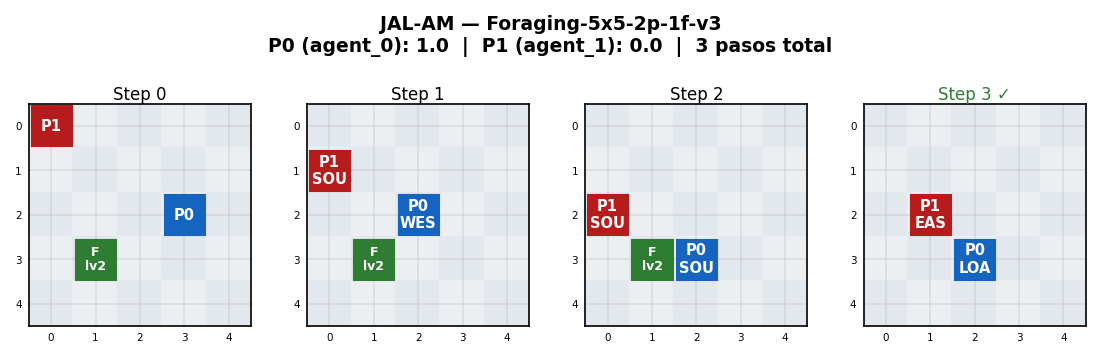

In [36]:
show_trained_game(game_jalam_0, agents_jalam_0, f'JAL-AM — {configurations["0"]["game"]}', save_path='figures/Foraging/jalam_config0_game.png')

#### Observaciones
En este experimento utilizando JAL-AM en `Foraging-5x5-2p-1f-v3` puede observarse un comportamiento similar al visto anteriormente con IQL, aunque ligeramente más estable durante el entrenamiento.

Las recompensas muestran nuevamente un escenario desbalanceado entre ambos agentes. El agente `agent\_0`} logra incrementar rápidamente su recompensa promedio hasta estabilizarse alrededor de valores cercanos a $0.7 - 0.8$, mientras que `agent\_1` mantiene recompensas considerablemente menores durante casi todo el entrenamiento.

Esto sugiere que uno de los agentes logra aprender una política más eficiente para alcanzar y recolectar el recurso disponible dentro del mapa. Sin embargo, a diferencia de IQL, las curvas parecen presentar menos oscilaciones y una evolución más estable a lo largo de las iteraciones.

Además, la visualización del episodio entrenado muestra que ambos agentes parecen moverse de forma relativamente coordinada hacia la comida. En los primeros pasos puede observarse que ambos agentes reducen progresivamente la distancia respecto al recurso hasta que finalmente uno de ellos ejecuta la acción de carga (`LOAD`) y recolecta la comida exitosamente en únicamente 3 pasos.

Esto sugiere que JAL-AM logra modelar parcialmente el comportamiento del otro agente y utilizar esa información para tomar decisiones más eficientes dentro del entorno. Sin embargo, el reparto final de recompensas continúa siendo desigual, indicando que el aprendizaje todavía favorece más a uno de los agentes que al otro.

En conjunto, los resultados muestran que JAL-AM logra un comportamiento más estable y coordinado que IQL en este ambiente pequeño de Foraging, aunque todavía no se observa una coordinación completamente balanceada entre ambos agentes.

### Configuración 1 — `Foraging-8x8-2p-1f-v3`

Grilla 8×8, 2 jugadores, 1 ítem. Mayor espacio de estado: 50 iteraciones × 100 episodios = 5 000 episodios totales.

=== IQL — Foraging-8x8-2p-1f-v3 ===
Entrenamiento: 50 iteraciones × 100 episodios
Estado inicial del episodio
  Comida: posición=(6, 2), nivel=2
  P0: posición=(4, 6), nivel=2
  P1: posición=(0, 1), nivel=2

Iteración 10 (1000 episodios)
  agent_0: 0.7300
  agent_1: 0.2200
Iteración 20 (2000 episodios)
  agent_0: 0.7500
  agent_1: 0.2500
Iteración 30 (3000 episodios)
  agent_0: 0.7100
  agent_1: 0.2800
Iteración 40 (4000 episodios)
  agent_0: 0.7050
  agent_1: 0.2950
Iteración 50 (5000 episodios)
  agent_0: 0.7300
  agent_1: 0.2700

Final — 50 iters × 100 eps = 5000 total episodes
  agent_0: 0.7300
  agent_1: 0.2700


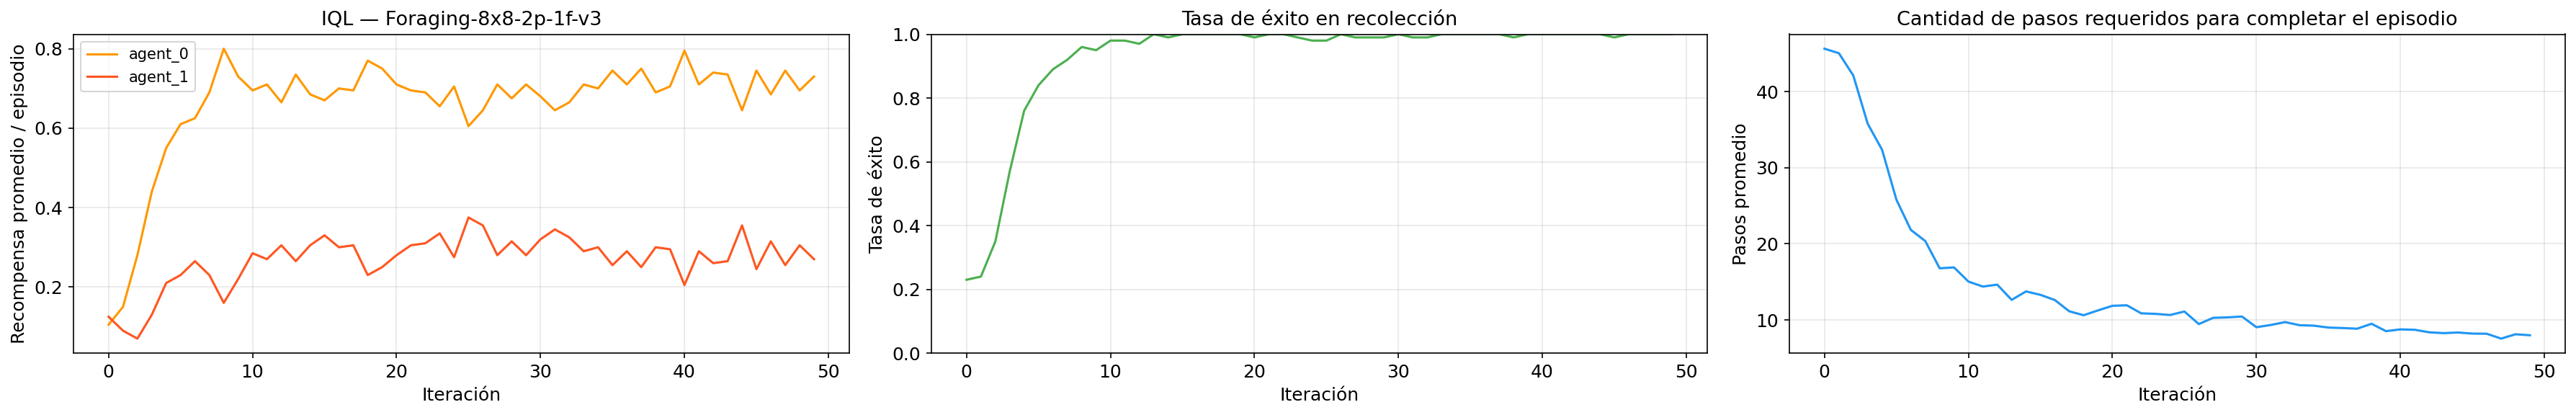

In [37]:
# ── IQL — Config 1: Foraging-8x8-2p-1f-v3 ────────────────────────────────────
config = configurations['1']
game_iql_1 = Foraging(config=config['game'], seed=1)
agents_iql_1 = {a: IndependentQLearning(game=game_iql_1, agent=a, **config['iql'])
                for a in game_iql_1.agents}

print(f"=== IQL — {config['game']} ===")
avg_iql_1, success_iql_1, steps_iql_1 = train(game_iql_1, agents_iql_1, config['train_config'], progress=True)

plot_training(avg_iql_1,
              title=f"IQL — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722'],
              save_path='figures/Foraging/iql_config1_training.png',
              success_rates=success_iql_1, avg_steps=steps_iql_1)

for a in game_iql_1.agents:
    agents_iql_1[a].epsilon = 0.0
    agents_iql_1[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


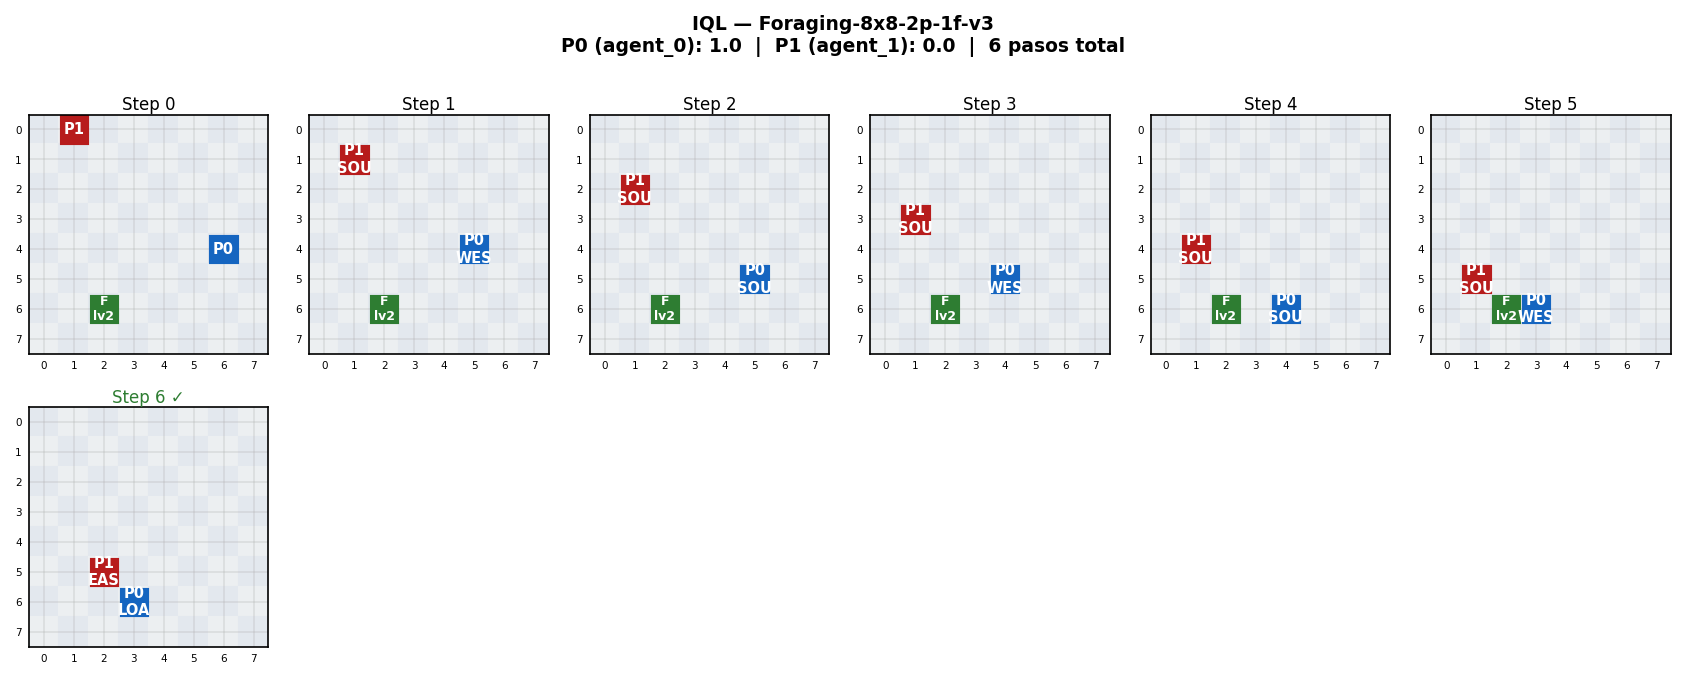

In [38]:
show_trained_game(game_iql_1, agents_iql_1, f'IQL — {configurations["1"]["game"]}', save_path='figures/Foraging/iql_config1_game.png')

#### Observaciones
En este experimento utilizando Independent Q-Learning en `Foraging-8x8-2p-1f-v3` puede observarse un comportamiento similar al visto en la configuración 5x5, aunque el ambiente más grande introduce una mayor dificultad para los agentes.

Las recompensas muestran nuevamente un escenario desbalanceado entre ambos agentes. El agente `agent_0` logra incrementar rápidamente su recompensa promedio hasta estabilizarse alrededor de valores cercanos a $0.7 - 0.8$, mientras que `agent_1` mantiene recompensas considerablemente menores durante casi todo el entrenamiento.

Sin embargo, en comparación con el ambiente 5x5, las recompensas presentan mayores fluctuaciones y una convergencia más lenta durante las primeras iteraciones. Esto resulta razonable ya que el mapa 8x8 posee un espacio de estados más grande, requiriendo mayor exploración para encontrar estrategias efectivas.

Además, la visualización del episodio entrenado muestra que ambos agentes logran desplazarse hacia la comida eficientemente. Puede observarse que el agente `P0` alcanza primero la posición cercana al recurso y finalmente ejecuta la acción `LOAD`, recolectando exitosamente la comida luego de 6 pasos.

El hecho de que ambos agentes se aproximen al recurso sugiere cierto grado de aprendizaje útil del entorno. Sin embargo, nuevamente el reparto de recompensas termina siendo desigual, indicando que uno de los agentes aprende una política significativamente más efectiva que el otro.

También puede observarse que la cantidad total de pasos necesarios para completar el episodio aumenta respecto al ambiente 5x5, algo esperable debido al mayor tamaño del mapa y a la necesidad de recorrer mayores distancias para alcanzar el recurso.

En conjunto, los resultados muestran que IQL continúa siendo capaz de aprender estrategias útiles en ambientes más grandes de Foraging, aunque las dificultades asociadas a la exploración y a la no estacionariedad del entorno se vuelven más evidentes a medida que aumenta la complejidad del problema.

=== JAL-AM — Foraging-8x8-2p-1f-v3 ===
Entrenamiento: 50 iteraciones × 100 episodios
Estado inicial del episodio
  Comida: posición=(6, 2), nivel=2
  P0: posición=(4, 6), nivel=2
  P1: posición=(0, 1), nivel=2

Iteración 10 (1000 episodios)
  agent_0: 0.6450
  agent_1: 0.3150
Iteración 20 (2000 episodios)
  agent_0: 0.6500
  agent_1: 0.3400
Iteración 30 (3000 episodios)
  agent_0: 0.6800
  agent_1: 0.3200
Iteración 40 (4000 episodios)
  agent_0: 0.6800
  agent_1: 0.3200
Iteración 50 (5000 episodios)
  agent_0: 0.6250
  agent_1: 0.3750

Final — 50 iters × 100 eps = 5000 total episodes
  agent_0: 0.6250
  agent_1: 0.3750


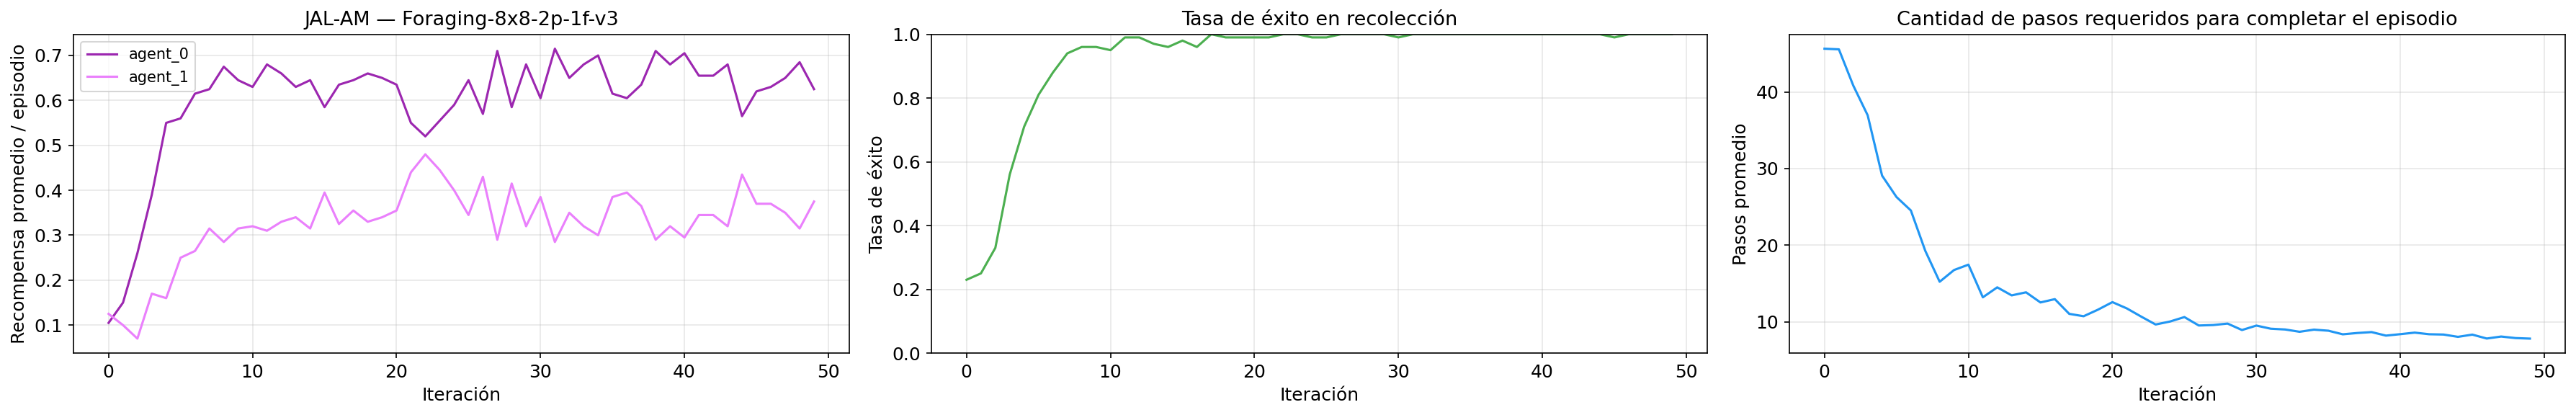

In [39]:
# ── JAL-AM — Config 1: Foraging-8x8-2p-1f-v3 ─────────────────────────────────
config = configurations['1']
game_jalam_1 = Foraging(config=config['game'], seed=1)
agents_jalam_1 = {a: JointActionLearningAM(game=game_jalam_1, agent=a, **config['jalam'])
                  for a in game_jalam_1.agents}

print(f"=== JAL-AM — {config['game']} ===")
avg_jalam_1, success_jalam_1, steps_jalam_1 = train(game_jalam_1, agents_jalam_1, config['train_config'], progress=True)

plot_training(avg_jalam_1,
              title=f"JAL-AM — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1]],
              save_path='figures/Foraging/jalam_config1_training.png',
              success_rates=success_jalam_1, avg_steps=steps_jalam_1)

for a in game_jalam_1.agents:
    agents_jalam_1[a].epsilon = 0.0
    agents_jalam_1[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


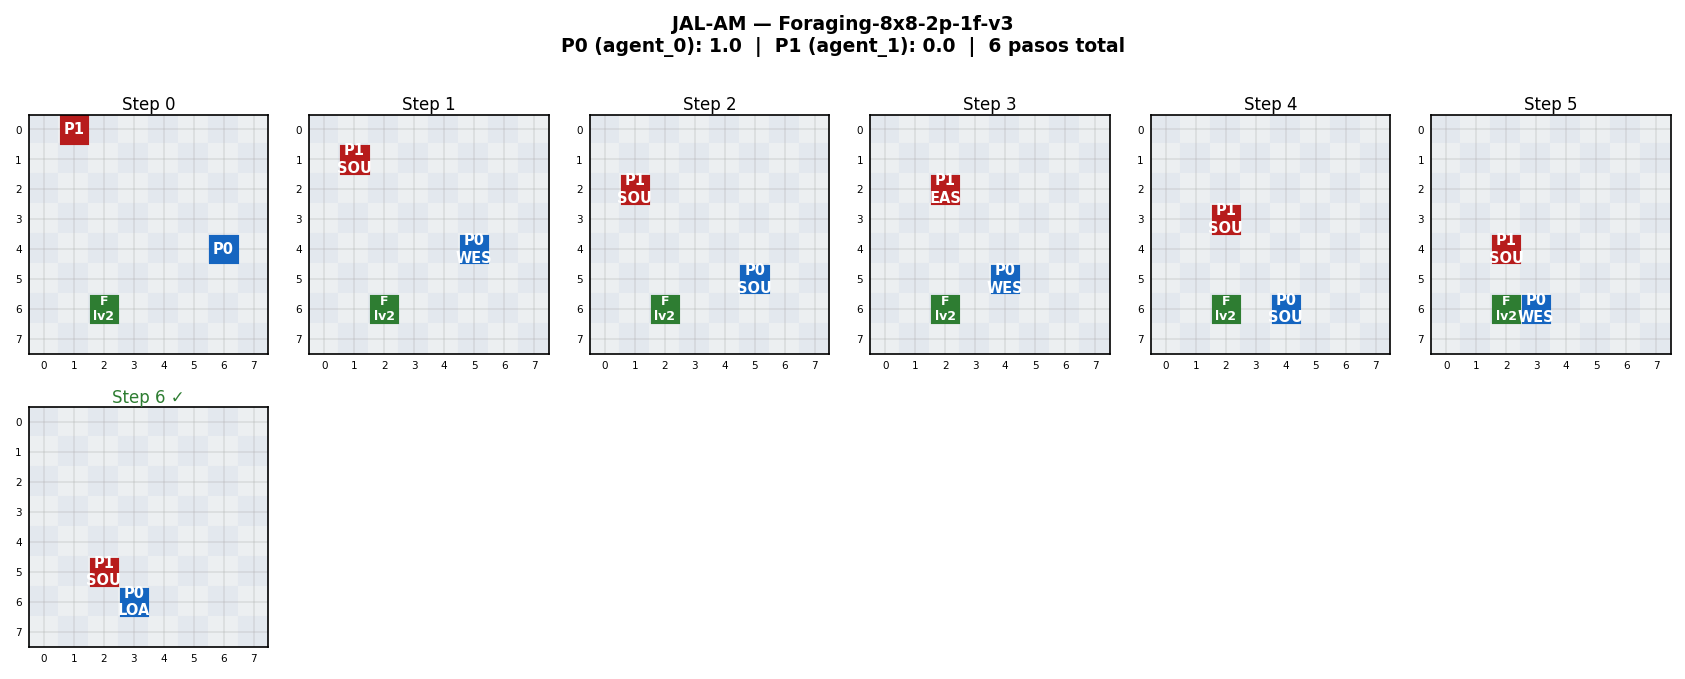

In [40]:
show_trained_game(game_jalam_1, agents_jalam_1, f'JAL-AM — {configurations["1"]["game"]}', save_path='figures/Foraging/jalam_config1_game.png')

#### Observaciones
En este experimento utilizando JAL-AM en `Foraging-8x8-2p-1f-v3` puede observarse un comportamiento relativamente más estable que el obtenido previamente con IQL en el mismo ambiente.

Las recompensas muestran nuevamente un escenario desbalanceado entre ambos agentes, donde `agent_0` obtiene consistentemente recompensas promedio considerablemente mayores que `agent_1`. Sin embargo, en este caso el segundo agente logra mantener recompensas más altas y estables que las observadas con IQL, sugiriendo una mejor adaptación al entorno.

Además, las curvas presentan una evolución más suave y con menos fluctuaciones bruscas durante el entrenamiento. Esto indica que JAL-AM logra estabilizar parcialmente el aprendizaje gracias al modelado explícito de las acciones del otro agente.

La visualización del episodio entrenado también muestra un comportamiento interesante. Ambos agentes se mueven de manera eficiente hacia la comida, acercándose progresivamente al recurso hasta que finalmente `P0` ejecuta la acción `LOAD` y recolecta exitosamente la comida luego de 6 pasos.

Puede observarse además que ambos agentes terminan muy próximos al recurso al finalizar el episodio, lo cual sugiere cierto grado de coordinación implícita o al menos una mejor comprensión compartida del objetivo dentro del entorno.

Al igual que en la configuración anterior, el aumento del tamaño del mapa introduce una mayor dificultad de exploración y requiere trayectorias más largas para alcanzar el recurso. Sin embargo, JAL-AM parece adaptarse relativamente bien a esta complejidad adicional y mantener un comportamiento más estable que IQL.

En conjunto, los resultados muestran que JAL-AM logra aprender políticas efectivas y relativamente estables en ambientes más grandes de Foraging. Aunque continúa existiendo un reparto desigual de recompensas entre agentes, el modelado del oponente parece ayudar a mejorar la coordinación y reducir parcialmente los problemas de no estacionariedad presentes en Independent Q-Learning.

### Configuración 2 — `Foraging-8x8-3p-1f-v3`

Grilla 8×8, **3 jugadores**, 1 ítem. Espacio de estado y acción conjunto más grande: 100 iteraciones × 100 episodios = 10 000 episodios totales.

=== IQL — Foraging-8x8-3p-1f-v3 ===
Entrenamiento: 100 iteraciones × 100 episodios
Estado inicial del episodio
  Comida: posición=(5, 2), nivel=2
  P0: posición=(0, 1), nivel=2
  P1: posición=(7, 1), nivel=1
  P2: posición=(6, 3), nivel=1

Iteración 10 (1000 episodios)
  agent_0: 0.1800
  agent_1: 0.0300
  agent_2: 0.0700
Iteración 20 (2000 episodios)
  agent_0: 0.1933
  agent_1: 0.2183
  agent_2: 0.2183
Iteración 30 (3000 episodios)
  agent_0: 0.1667
  agent_1: 0.3083
  agent_2: 0.3450
Iteración 40 (4000 episodios)
  agent_0: 0.1317
  agent_1: 0.3608
  agent_2: 0.3875
Iteración 50 (5000 episodios)
  agent_0: 0.1367
  agent_1: 0.3883
  agent_2: 0.3950
Iteración 60 (6000 episodios)
  agent_0: 0.1067
  agent_1: 0.4217
  agent_2: 0.4417
Iteración 70 (7000 episodios)
  agent_0: 0.1500
  agent_1: 0.3983
  agent_2: 0.4317
Iteración 80 (8000 episodios)
  agent_0: 0.1000
  agent_1: 0.4283
  agent_2: 0.4217
Iteración 90 (9000 episodios)
  agent_0: 0.0983
  agent_1: 0.4358
  agent_2: 0.4258
Iter

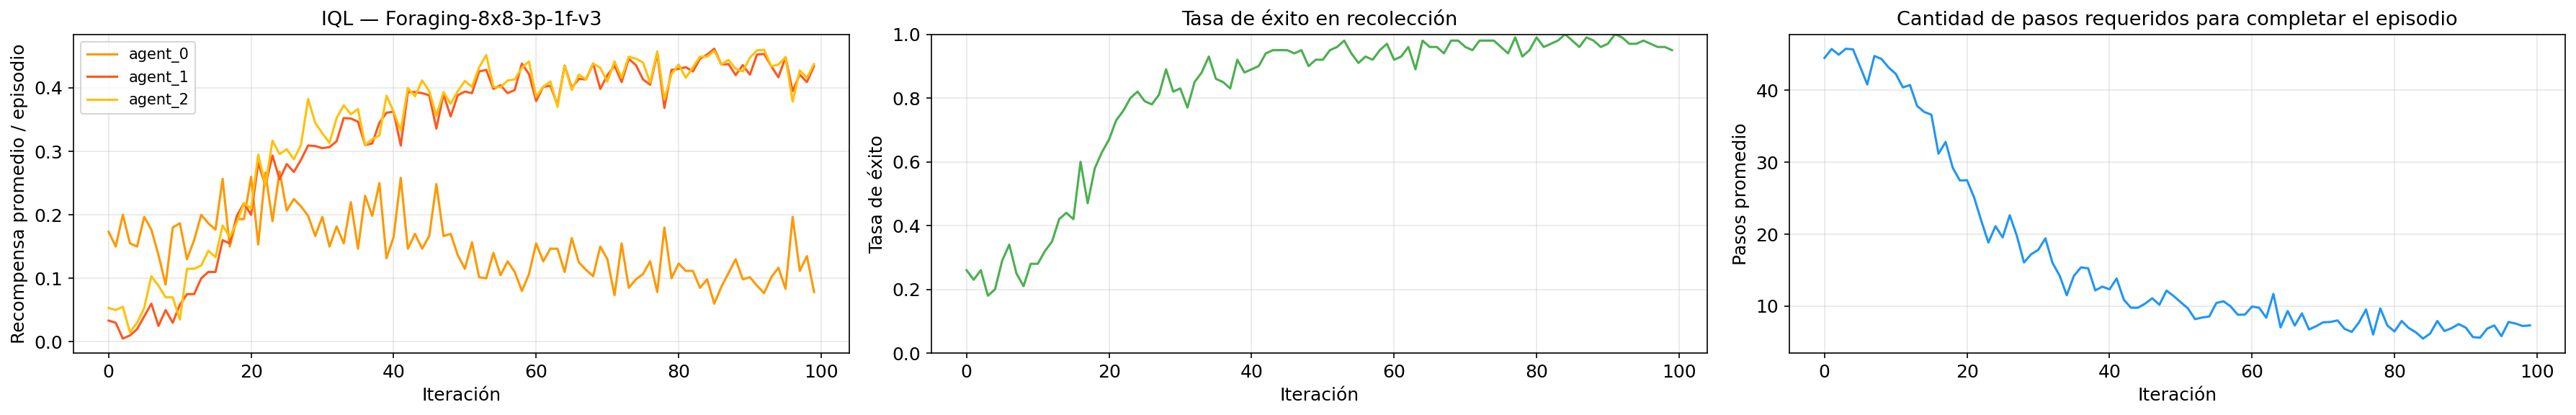

In [41]:
# ── IQL — Config 2: Foraging-8x8-3p-1f-v3 ────────────────────────────────────
config = configurations['2']
game_iql_2 = Foraging(config=config['game'], seed=1)
agents_iql_2 = {a: IndependentQLearning(game=game_iql_2, agent=a, **config['iql'])
                for a in game_iql_2.agents}

print(f"=== IQL — {config['game']} ===")
avg_iql_2, success_iql_2, steps_iql_2 = train(game_iql_2, agents_iql_2, config['train_config'], progress=True)

plot_training(avg_iql_2,
              title=f"IQL — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722', '#FFC107'],
              save_path='figures/Foraging/iql_config2_training.png',
              success_rates=success_iql_2, avg_steps=steps_iql_2)

for a in game_iql_2.agents:
    agents_iql_2[a].epsilon = 0.0
    agents_iql_2[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


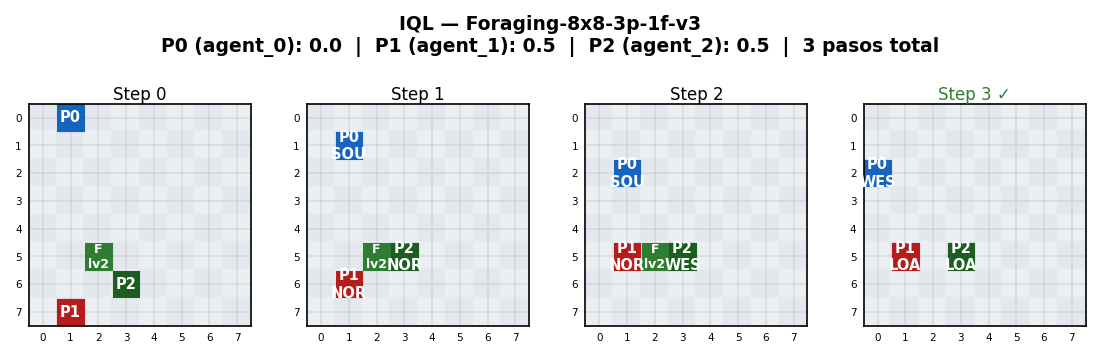

In [42]:
show_trained_game(game_iql_2, agents_iql_2, f'IQL — {configurations["2"]["game"]}', save_path='figures/Foraging/iql_config2_game.png')

#### Observaciones

En este experimento utilizando Independent Q-Learning en `Foraging-8x8-3p-1f-v3` puede observarse un comportamiento diferente respecto a las configuraciones anteriores con únicamente dos agentes.

Las recompensas muestran una dinámica más distribuida entre los jugadores. Mientras que `agent_1` y `agent_2` logran incrementar progresivamente sus recompensas promedio hasta alcanzar valores cercanos a $0.4 - 0.45$, `agent_0` mantiene recompensas considerablemente menores durante gran parte del entrenamiento.

A diferencia de los escenarios de dos jugadores, aquí puede observarse que dos agentes parecen beneficiarse simultáneamente del aprendizaje, mientras que un tercer agente queda parcialmente desplazado. Esto sugiere que la presencia de un tercer jugador aumenta la complejidad de coordinación dentro del entorno.

La visualización del episodio entrenado muestra que `P1` y `P2` ejecutan la acción `LOAD` cerca del recurso, mientras que `P0` permanece más alejado. Como resultado, las recompensas finales fueron aproximadamente: `P0 = 0.0`, `P1 = 0.5` y `P2 = 0.5`.

Esto sugiere que algunos agentes lograron coordinarse mejor que otros para recolectar exitosamente la comida. Además, el episodio se completa en únicamente 3 pasos, indicando que los agentes aprendieron una trayectoria eficiente hacia el recurso.

En conjunto, los resultados muestran que IQL logra aprender comportamientos útiles incluso en escenarios con tres agentes, aunque la coordinación y distribución de recompensas se vuelven más complejas a medida que aumenta la cantidad de jugadores.

=== JAL-AM — Foraging-8x8-3p-1f-v3 ===
Entrenamiento: 100 iteraciones × 100 episodios
Estado inicial del episodio
  Comida: posición=(5, 2), nivel=2
  P0: posición=(0, 1), nivel=2
  P1: posición=(7, 1), nivel=1
  P2: posición=(6, 3), nivel=1

Iteración 10 (1000 episodios)
  agent_0: 0.1700
  agent_1: 0.0400
  agent_2: 0.0900
Iteración 20 (2000 episodios)
  agent_0: 0.2667
  agent_1: 0.1667
  agent_2: 0.2067
Iteración 30 (3000 episodios)
  agent_0: 0.3650
  agent_1: 0.2525
  agent_2: 0.2725
Iteración 40 (4000 episodios)
  agent_0: 0.1883
  agent_1: 0.3275
  agent_2: 0.3242
Iteración 50 (5000 episodios)
  agent_0: 0.1483
  agent_1: 0.3842
  agent_2: 0.3775
Iteración 60 (6000 episodios)
  agent_0: 0.1400
  agent_1: 0.4033
  agent_2: 0.3967
Iteración 70 (7000 episodios)
  agent_0: 0.1850
  agent_1: 0.3975
  agent_2: 0.4075
Iteración 80 (8000 episodios)
  agent_0: 0.1667
  agent_1: 0.4100
  agent_2: 0.4233
Iteración 90 (9000 episodios)
  agent_0: 0.1400
  agent_1: 0.4233
  agent_2: 0.3967
I

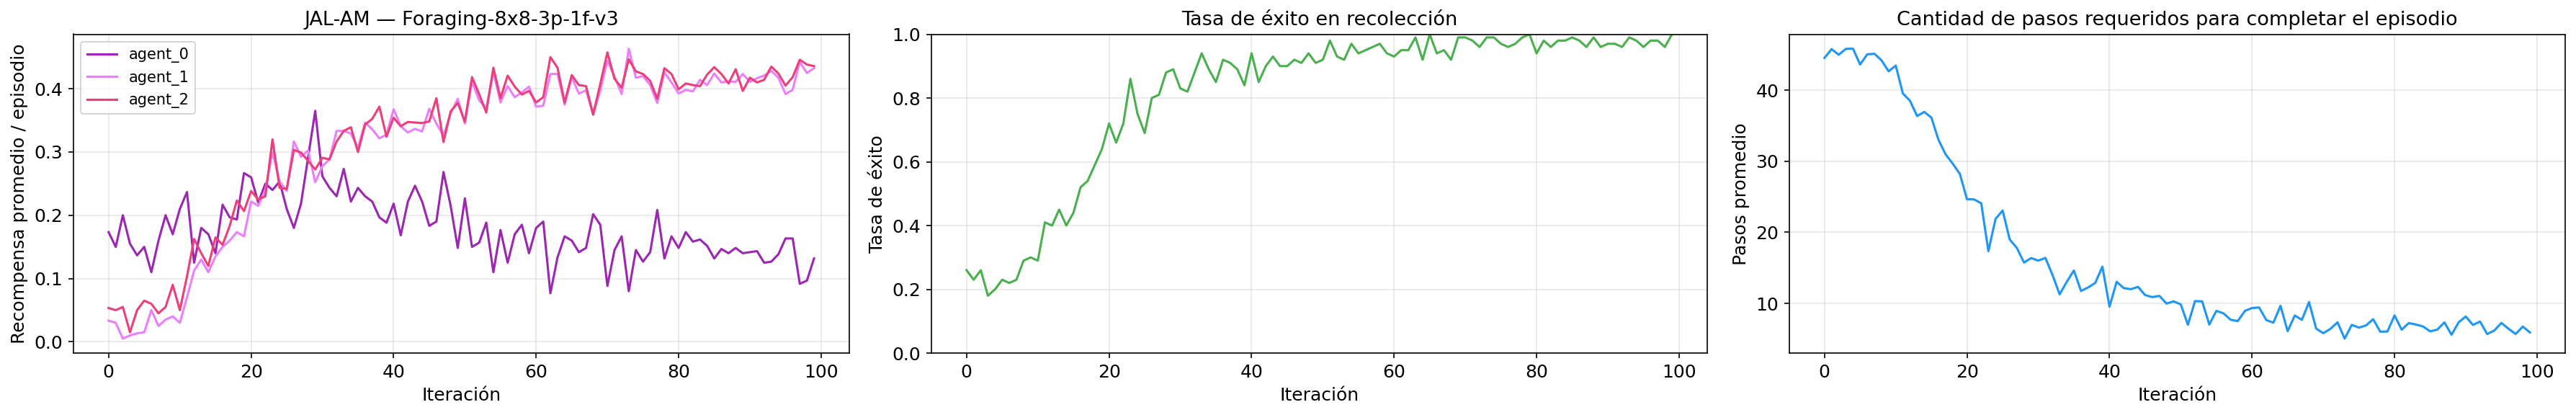

In [43]:
# ── JAL-AM — Config 2: Foraging-8x8-3p-1f-v3 ─────────────────────────────────
config = configurations['2']
game_jalam_2 = Foraging(config=config['game'], seed=1)
agents_jalam_2 = {a: JointActionLearningAM(game=game_jalam_2, agent=a, **config['jalam'])
                  for a in game_jalam_2.agents}

print(f"=== JAL-AM — {config['game']} ===")
avg_jalam_2, success_jalam_2, steps_jalam_2 = train(game_jalam_2, agents_jalam_2, config['train_config'], progress=True)

plot_training(avg_jalam_2,
              title=f"JAL-AM — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1], JAL_AM_PALETTE[2]],
              save_path='figures/Foraging/jalam_config2_training.png',
              success_rates=success_jalam_2, avg_steps=steps_jalam_2)

for a in game_jalam_2.agents:
    agents_jalam_2[a].epsilon = 0.0
    agents_jalam_2[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


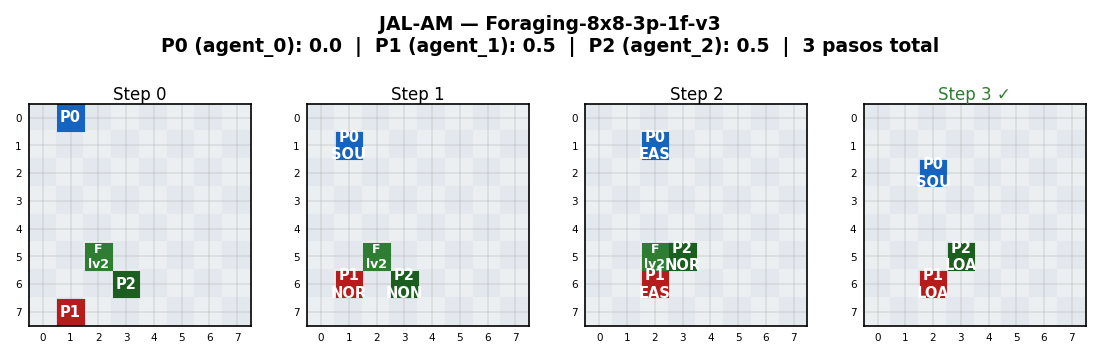

In [44]:
show_trained_game(game_jalam_2, agents_jalam_2, f'JAL-AM — {configurations["2"]["game"]}', save_path='figures/Foraging/jalam_config2_game.png')

#### Observaciones

En este experimento utilizando JAL-AM en `Foraging-8x8-3p-1f-v3` puede observarse un comportamiento bastante similar al obtenido previamente con IQL en la misma configuración.

Las recompensas muestran nuevamente un escenario desbalanceado entre agentes. Tanto `agent_1` como `agent_2` logran incrementar progresivamente sus recompensas promedio hasta estabilizarse alrededor de `0.4 - 0.45`, mientras que `agent_0` mantiene recompensas considerablemente menores durante gran parte del entrenamiento.

Aunque las curvas parecen ligeramente más suaves que en IQL, las diferencias generales entre ambos algoritmos no resultan demasiado marcadas en este entorno. Continúa observándose que algunos agentes logran adaptarse mejor que otros y terminan obteniendo la mayor parte de las recompensas disponibles.

La visualización del episodio entrenado muestra además una dinámica muy parecida a la observada previamente con IQL. Tanto `P1` como `P2` terminan cerca del recurso y obtienen recompensas compartidas, mientras que `P0` permanece considerablemente más alejado.

Las recompensas finales observadas fueron:

- `P0 = 0.0`
- `P1 = 0.5`
- `P2 = 0.5`

También resulta interesante observar que el agente con menores recompensas vuelve a coincidir con el agente más alejado de la comida durante el episodio. Esto podría indicar que pequeñas diferencias iniciales de posicionamiento o exploración terminan amplificándose durante el entrenamiento, favoreciendo sistemáticamente a ciertos agentes.

En conjunto, los resultados sugieren que, al menos en esta configuración de Foraging, JAL-AM no logra una mejora significativamente superior respecto a IQL en términos de balance entre agentes o coordinación global. Ambos algoritmos aprenden políticas útiles para alcanzar el recurso, aunque continúan apareciendo distribuciones desbalanceadas de recompensas entre jugadores.

#### JAL-AM × 2 + IQL × 1 — Config 2

P0 y P1 usan **JAL-AM**; P2 usa **IQL**.

=== JAL-AM×2 + IQL×1 — Foraging-8x8-3p-1f-v3 ===
Entrenamiento: 100 iteraciones × 100 episodios
Estado inicial del episodio
  Comida: posición=(5, 2), nivel=2
  P0: posición=(0, 1), nivel=2
  P1: posición=(7, 1), nivel=1
  P2: posición=(6, 3), nivel=1

Iteración 10 (1000 episodios)
  agent_0: 0.1000
  agent_1: 0.0600
  agent_2: 0.0800
Iteración 20 (2000 episodios)
  agent_0: 0.1700
  agent_1: 0.2050
  agent_2: 0.2050
Iteración 30 (3000 episodios)
  agent_0: 0.2483
  agent_1: 0.3042
  agent_2: 0.2975
Iteración 40 (4000 episodios)
  agent_0: 0.2100
  agent_1: 0.3500
  agent_2: 0.3700
Iteración 50 (5000 episodios)
  agent_0: 0.2317
  agent_1: 0.3075
  agent_2: 0.3108
Iteración 60 (6000 episodios)
  agent_0: 0.2167
  agent_1: 0.3417
  agent_2: 0.3517
Iteración 70 (7000 episodios)
  agent_0: 0.1767
  agent_1: 0.3917
  agent_2: 0.4017
Iteración 80 (8000 episodios)
  agent_0: 0.1917
  agent_1: 0.3708
  agent_2: 0.3675
Iteración 90 (9000 episodios)
  agent_0: 0.1683
  agent_1: 0.3892
  agent_2

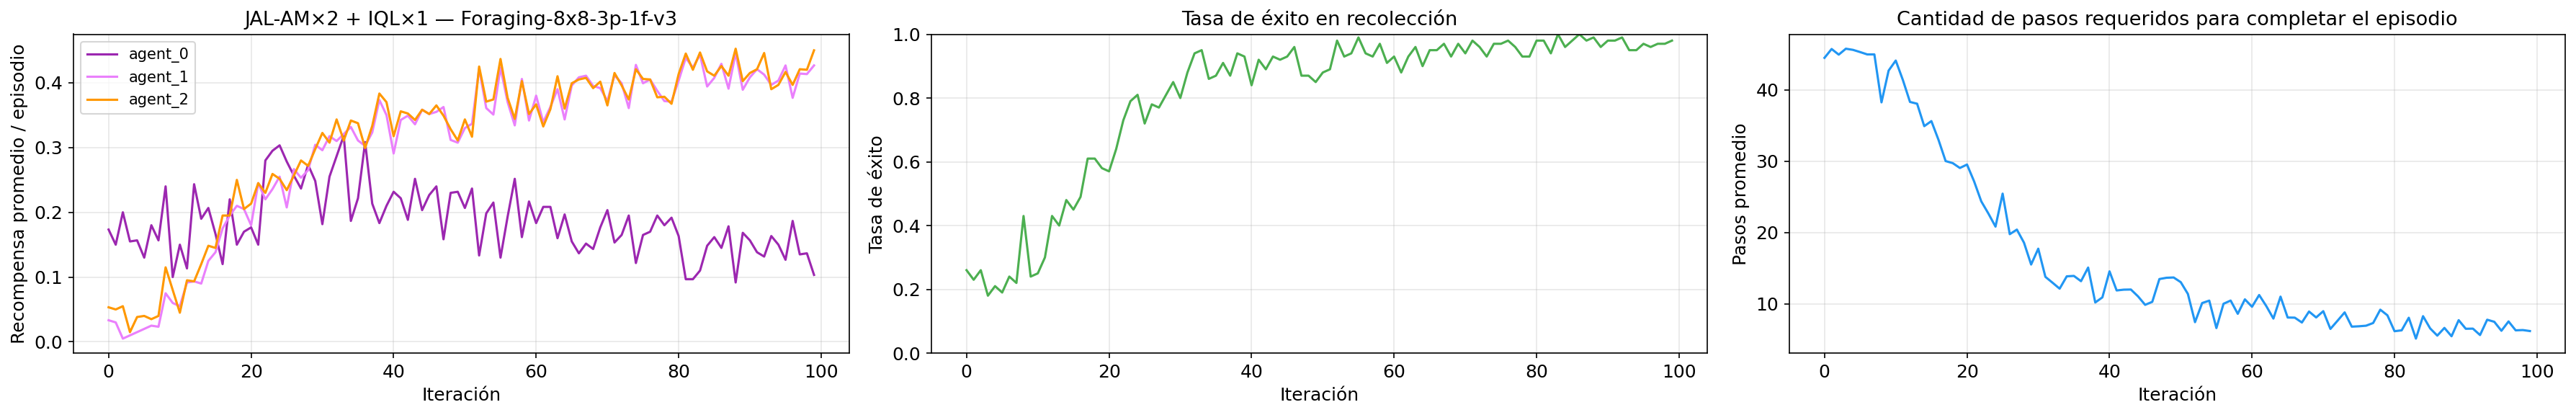

In [45]:
# ── JAL-AM×2 + IQL×1 — Config 2: Foraging-8x8-3p-1f-v3 ──────────────────────
config = configurations['2']
game_jalam2iql_2 = Foraging(config=config['game'], seed=1)
agents_jalam2iql_2 = {
    game_jalam2iql_2.agents[0]: JointActionLearningAM(game=game_jalam2iql_2, agent=game_jalam2iql_2.agents[0], **config['jalam']),
    game_jalam2iql_2.agents[1]: JointActionLearningAM(game=game_jalam2iql_2, agent=game_jalam2iql_2.agents[1], **config['jalam']),
    game_jalam2iql_2.agents[2]: IndependentQLearning(game=game_jalam2iql_2, agent=game_jalam2iql_2.agents[2], **config['iql']),
}

print(f"=== JAL-AM×2 + IQL×1 — {config['game']} ===")
avg_jalam2iql_2, success_jalam2iql_2, steps_jalam2iql_2 = train(game_jalam2iql_2, agents_jalam2iql_2, config['train_config'], progress=True)

plot_training(avg_jalam2iql_2,
              title=f"JAL-AM×2 + IQL×1 — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1], COLORS['IQL']],
              save_path='figures/Foraging/jalam2iql_config2_training.png',
              success_rates=success_jalam2iql_2, avg_steps=steps_jalam2iql_2)

for a in game_jalam2iql_2.agents:
    agents_jalam2iql_2[a].epsilon = 0.0
    agents_jalam2iql_2[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


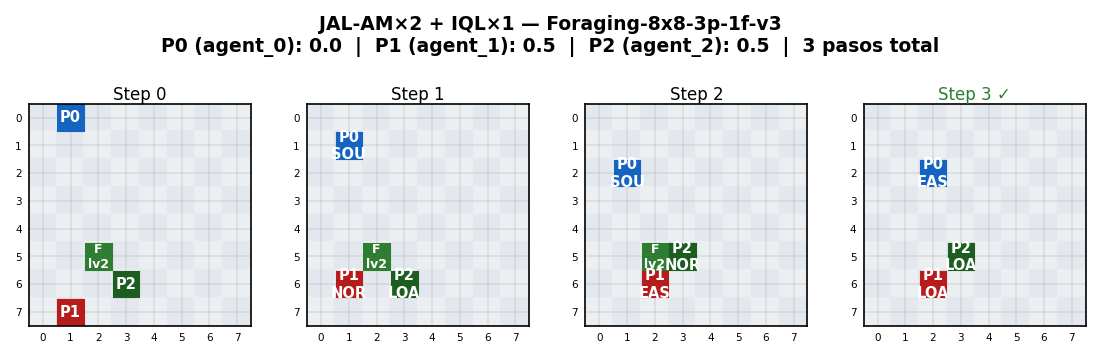

In [46]:
show_trained_game(game_jalam2iql_2, agents_jalam2iql_2, f'JAL-AM×2 + IQL×1 — {configurations["2"]["game"]}', save_path='figures/Foraging/jalam2iql_config2_game.png')

#### Observaciones

En este experimento se evaluó una configuración mixta en `Foraging-8x8-3p-1f-v3`, donde `P0` y `P1` utilizan JAL-AM mientras que `P2` utiliza IQL.

Las recompensas muestran un comportamiento bastante similar al observado en los experimentos anteriores con tres agentes. Nuevamente, dos agentes logran incrementar progresivamente sus recompensas promedio hasta estabilizarse alrededor de `0.4 - 0.45`, mientras que un tercer agente mantiene recompensas considerablemente menores durante casi todo el entrenamiento.

En este caso, los agentes con mejor desempeño fueron `agent_1` y `agent_2`, mientras que `agent_0` quedó claramente rezagado. Resulta interesante observar que el agente basado en IQL (`P2`) no parece verse perjudicado frente a los agentes JAL-AM; por el contrario, termina obteniendo recompensas similares a las del mejor agente del entorno.

Esto sugiere que, al menos en esta configuración particular, utilizar JAL-AM no genera una ventaja claramente observable respecto a IQL en términos de recompensa final o capacidad de coordinación.

La visualización del episodio entrenado muestra nuevamente una dinámica de cooperación parcial entre dos agentes. Tanto `P1` como `P2` terminan realizando acciones cercanas al recurso y obtienen recompensas compartidas, mientras que `P0` permanece más alejado de la comida.

Las recompensas finales observadas fueron:

- `P0 = 0.0`
- `P1 = 0.5`
- `P2 = 0.5`

Además, el episodio vuelve a completarse en únicamente `3 pasos`, indicando que los agentes aprendieron trayectorias eficientes hacia el recurso dentro del entorno.

También puede observarse nuevamente el patrón visto en experimentos anteriores: el agente con menores recompensas coincide con el agente que termina más lejos de la comida durante el episodio. Esto refuerza la hipótesis de que pequeñas diferencias iniciales de posicionamiento o exploración pueden amplificarse durante el entrenamiento y terminar favoreciendo sistemáticamente a ciertos agentes.

En conjunto, los resultados sugieren que mezclar agentes JAL-AM e IQL no modifica significativamente la dinámica general observada en Foraging. Continúan apareciendo distribuciones desbalanceadas de recompensas, y la coordinación efectiva parece emerger únicamente entre algunos agentes del entorno.

#### IQL × 2 + JAL-AM × 1 — Config 2

P0 y P1 usan **IQL**; P2 usa **JAL-AM**.

=== IQL×2 + JAL-AM×1 — Foraging-8x8-3p-1f-v3 ===
Entrenamiento: 100 iteraciones × 100 episodios
Estado inicial del episodio
  Comida: posición=(5, 2), nivel=2
  P0: posición=(0, 1), nivel=2
  P1: posición=(7, 1), nivel=1
  P2: posición=(6, 3), nivel=1

Iteración 10 (1000 episodios)
  agent_0: 0.1400
  agent_1: 0.0850
  agent_2: 0.0650
Iteración 20 (2000 episodios)
  agent_0: 0.1200
  agent_1: 0.2750
  agent_2: 0.2950
Iteración 30 (3000 episodios)
  agent_0: 0.1933
  agent_1: 0.3100
  agent_2: 0.3167
Iteración 40 (4000 episodios)
  agent_0: 0.2317
  agent_1: 0.3142
  agent_2: 0.3342
Iteración 50 (5000 episodios)
  agent_0: 0.2033
  agent_1: 0.3600
  agent_2: 0.3667
Iteración 60 (6000 episodios)
  agent_0: 0.1733
  agent_1: 0.3867
  agent_2: 0.3900
Iteración 70 (7000 episodios)
  agent_0: 0.1467
  agent_1: 0.4033
  agent_2: 0.4100
Iteración 80 (8000 episodios)
  agent_0: 0.1250
  agent_1: 0.4092
  agent_2: 0.4058
Iteración 90 (9000 episodios)
  agent_0: 0.0933
  agent_1: 0.4150
  agent_2

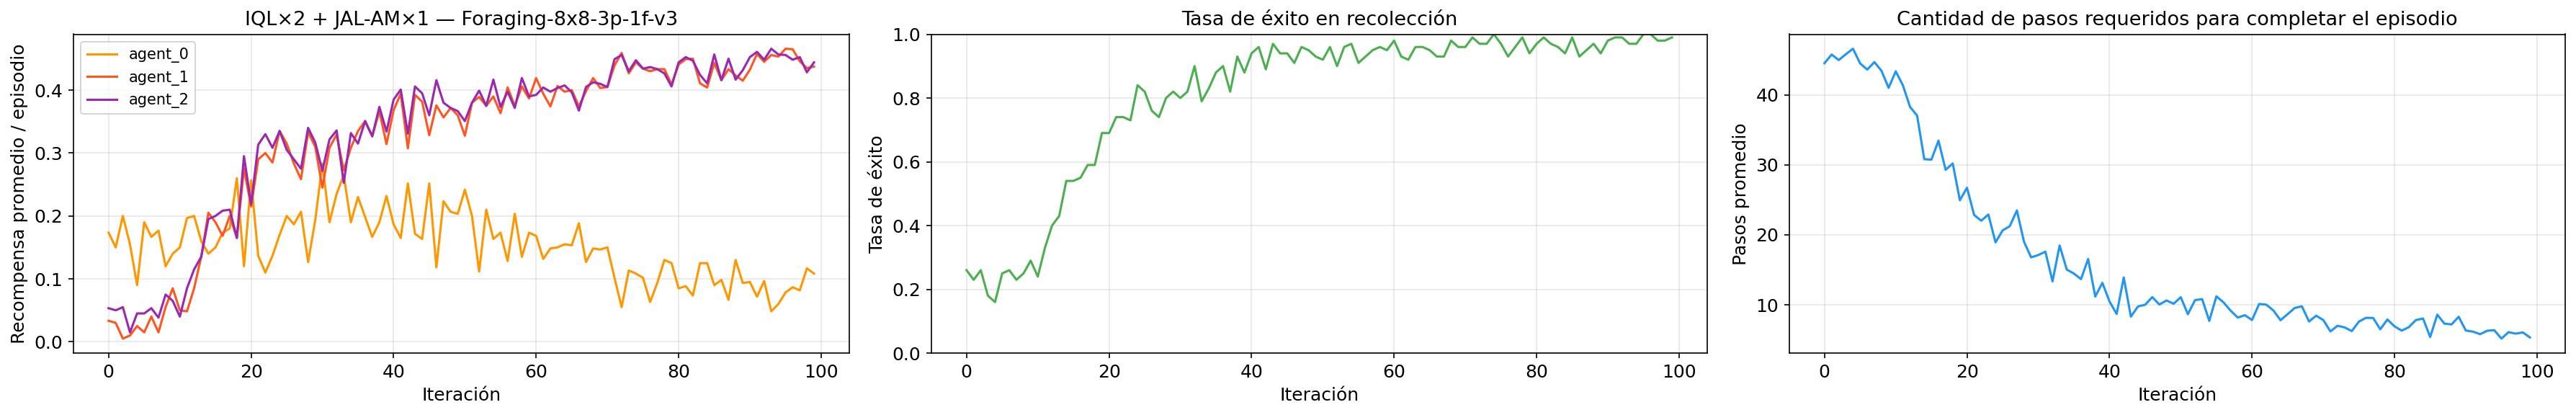

In [47]:
# ── IQL×2 + JAL-AM×1 — Config 2: Foraging-8x8-3p-1f-v3 ──────────────────────
config = configurations['2']
game_iql2jalam_2 = Foraging(config=config['game'], seed=1)
agents_iql2jalam_2 = {
    game_iql2jalam_2.agents[0]: IndependentQLearning(game=game_iql2jalam_2, agent=game_iql2jalam_2.agents[0], **config['iql']),
    game_iql2jalam_2.agents[1]: IndependentQLearning(game=game_iql2jalam_2, agent=game_iql2jalam_2.agents[1], **config['iql']),
    game_iql2jalam_2.agents[2]: JointActionLearningAM(game=game_iql2jalam_2, agent=game_iql2jalam_2.agents[2], **config['jalam']),
}

print(f"=== IQL×2 + JAL-AM×1 — {config['game']} ===")
avg_iql2jalam_2, success_iql2jalam_2, steps_iql2jalam_2 = train(game_iql2jalam_2, agents_iql2jalam_2, config['train_config'], progress=True)

plot_training(avg_iql2jalam_2,
              title=f"IQL×2 + JAL-AM×1 — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722', JAL_AM_PALETTE[0]],
              save_path='figures/Foraging/iql2jalam_config2_training.png',
              success_rates=success_iql2jalam_2, avg_steps=steps_iql2jalam_2)

for a in game_iql2jalam_2.agents:
    agents_iql2jalam_2[a].epsilon = 0.0
    agents_iql2jalam_2[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


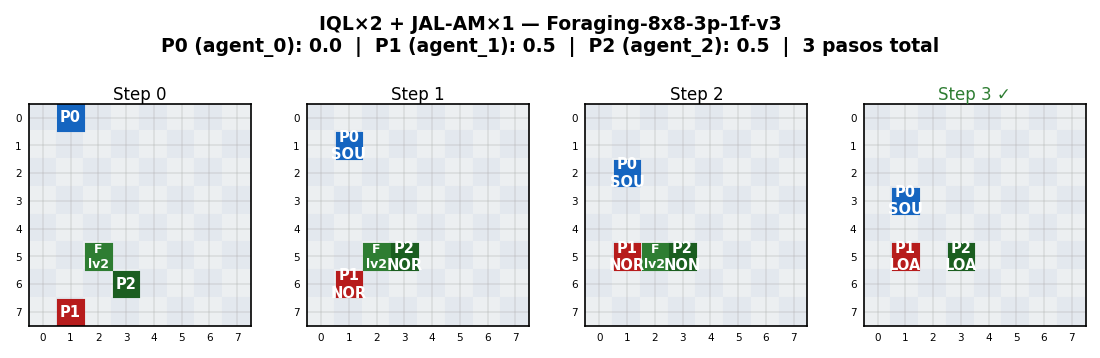

In [48]:
show_trained_game(game_iql2jalam_2, agents_iql2jalam_2, f'IQL×2 + JAL-AM×1 — {configurations["2"]["game"]}', save_path='figures/Foraging/iql2jalam_config2_game.png')

#### Observaciones

En este experimento se evaluó una configuración mixta en `Foraging-8x8-3p-1f-v3`, donde `P0` y `P1` utilizan IQL mientras que `P2` utiliza JAL-AM.

Las recompensas muestran nuevamente un escenario desbalanceado entre agentes. Tanto `agent_1` como `agent_2` logran incrementar progresivamente sus recompensas promedio hasta estabilizarse alrededor de `0.4 - 0.45`, mientras que `agent_0` mantiene recompensas considerablemente menores durante gran parte del entrenamiento.

Resulta interesante observar que el agente JAL-AM (`P2`) obtiene recompensas similares a uno de los agentes IQL (`P1`), mientras que el otro agente IQL (`P0`) queda claramente relegado. Esto sugiere que el tipo de algoritmo utilizado no parece ser el único factor determinante del desempeño dentro de este entorno.

Las curvas presentan una evolución relativamente estable luego de las primeras iteraciones, indicando que los agentes logran aprender estrategias eficientes para alcanzar rápidamente el recurso disponible.

La visualización del episodio entrenado muestra nuevamente una dinámica de cooperación parcial entre dos agentes. En este caso, `P1` y `P2` terminan ejecutando acciones `LOAD` cerca de la comida y obtienen recompensas compartidas, mientras que `P0` permanece más alejado del recurso.

Las recompensas finales observadas fueron:

- `P0 = 0.0`
- `P1 = 0.5`
- `P2 = 0.5`

Además, el episodio vuelve a completarse en únicamente `3 pasos`, mostrando que los agentes aprendieron trayectorias muy eficientes dentro del mapa.

Al igual que en los experimentos anteriores, vuelve a observarse que el agente con peores recompensas coincide con el agente que termina más lejos de la comida durante el episodio. Esto refuerza la hipótesis de que pequeñas diferencias iniciales de posicionamiento o exploración pueden amplificarse durante el entrenamiento y favorecer sistemáticamente a ciertos agentes.

En conjunto, los resultados sugieren que combinar IQL y JAL-AM no modifica significativamente la dinámica general observada en Foraging. Continúan apareciendo distribuciones desbalanceadas de recompensas y la cooperación efectiva parece emerger únicamente entre algunos agentes del entorno, independientemente del algoritmo utilizado.

### Configuración 3 — `Foraging-8x8-3p-1f-coop-v3`

Grilla 8×8, **3 jugadores**, 1 ítem, **modo cooperativo** (`force_coop=True`). La cooperación es obligatoria en todos los episodios. Horizonte largo: 100 iteraciones × 1 000 episodios = 100 000 episodios totales.

=== IQL — Foraging-8x8-3p-1f-coop-v3 ===
Entrenamiento: 100 iteraciones × 1000 episodios
Estado inicial del episodio
  Comida: posición=(5, 2), nivel=4
  P0: posición=(0, 1), nivel=2
  P1: posición=(7, 1), nivel=1
  P2: posición=(6, 3), nivel=1

Iteración 10 (10000 episodios)
  agent_0: 0.4310
  agent_1: 0.2155
  agent_2: 0.2155
Iteración 20 (20000 episodios)
  agent_0: 0.4760
  agent_1: 0.2380
  agent_2: 0.2380
Iteración 30 (30000 episodios)
  agent_0: 0.4900
  agent_1: 0.2450
  agent_2: 0.2450
Iteración 40 (40000 episodios)
  agent_0: 0.4950
  agent_1: 0.2475
  agent_2: 0.2475
Iteración 50 (50000 episodios)
  agent_0: 0.4925
  agent_1: 0.2462
  agent_2: 0.2462
Iteración 60 (60000 episodios)
  agent_0: 0.4965
  agent_1: 0.2482
  agent_2: 0.2482
Iteración 70 (70000 episodios)
  agent_0: 0.4995
  agent_1: 0.2497
  agent_2: 0.2497
Iteración 80 (80000 episodios)
  agent_0: 0.4995
  agent_1: 0.2497
  agent_2: 0.2497
Iteración 90 (90000 episodios)
  agent_0: 0.4990
  agent_1: 0.2495
  agent

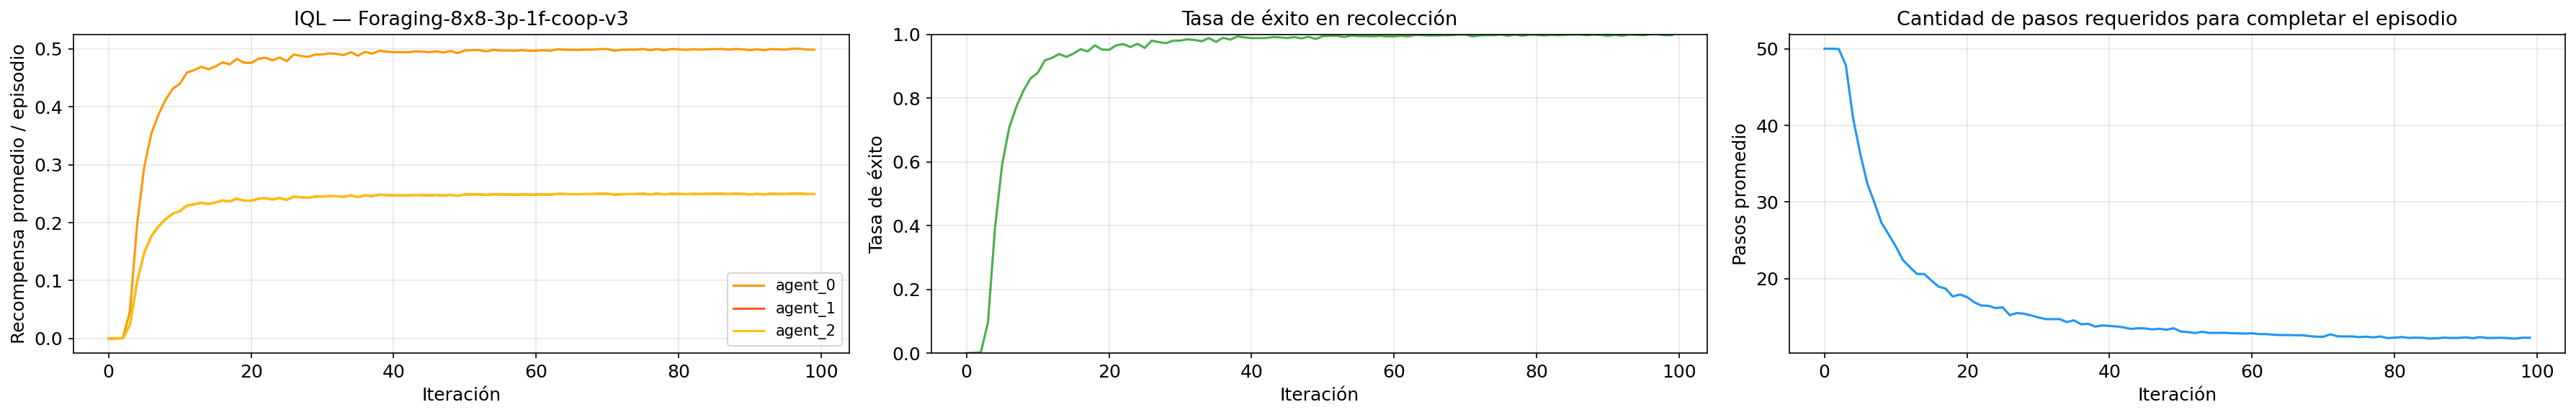

In [49]:
# ── IQL — Config 3: Foraging-8x8-3p-1f-coop-v3 ───────────────────────────────
config = configurations['3']
game_iql_3 = Foraging(config=config['game'], seed=1)
agents_iql_3 = {a: IndependentQLearning(game=game_iql_3, agent=a, **config['iql'])
                for a in game_iql_3.agents}

print(f"=== IQL — {config['game']} ===")
avg_iql_3, success_iql_3, steps_iql_3 = train(game_iql_3, agents_iql_3, config['train_config'], progress=True)

plot_training(avg_iql_3,
              title=f"IQL — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722', '#FFC107'],
              save_path='figures/Foraging/iql_config3_training.png',
              success_rates=success_iql_3, avg_steps=steps_iql_3)

for a in game_iql_3.agents:
    agents_iql_3[a].epsilon = 0.0
    agents_iql_3[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_35847/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


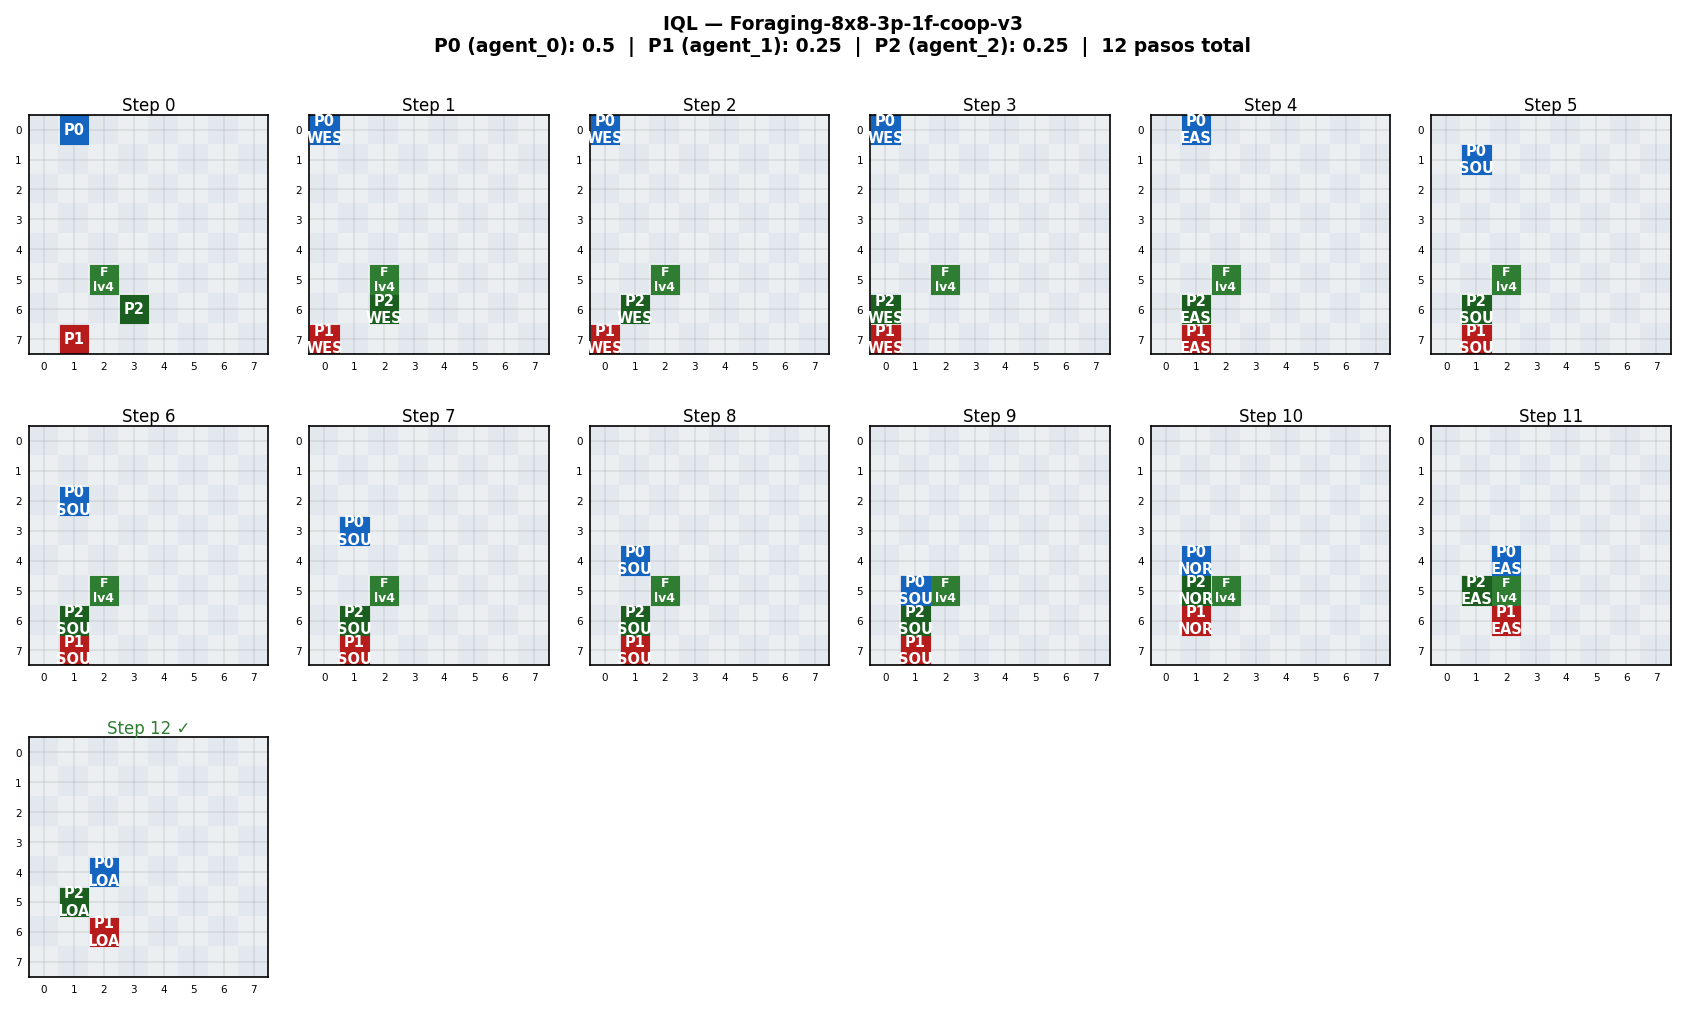

In [50]:
show_trained_game(game_iql_3, agents_iql_3, f'IQL — {configurations["3"]["game"]}', save_path='figures/Foraging/iql_config3_game.png')

#### Observaciones

En este experimento se evaluó una configuración cooperativa utilizando IQL en `Foraging-8x8-3p-1f-coop-v3`.

A diferencia de los escenarios anteriores, aquí puede observarse un comportamiento considerablemente más coordinado entre los agentes. Las recompensas muestran una convergencia muy rápida durante las primeras iteraciones y luego permanecen extremadamente estables durante el resto del entrenamiento.

Además, las recompensas no aparecen tan desbalanceadas como en los experimentos no cooperativos. Aunque `agent_0` obtiene una recompensa promedio mayor (cercana a `0.5`), tanto `agent_1` como `agent_2` logran mantener recompensas relativamente similares y estables alrededor de `0.25`.

Esto sugiere que la configuración cooperativa modifica significativamente la dinámica del aprendizaje. En lugar de competir implícitamente por alcanzar primero el recurso, los agentes parecen desarrollar estrategias donde colaborar resulta beneficioso para todos.

La visualización del episodio entrenado refuerza claramente esta idea. Durante gran parte del episodio puede observarse cómo los tres agentes convergen progresivamente hacia la posición de la comida y permanecen relativamente agrupados cerca del recurso.

Además, el recurso posee:

- `food level = 4`

mientras que los agentes parecen tener niveles menores individualmente, por lo que la cooperación resulta necesaria para poder ejecutar exitosamente la acción `LOAD`.

Las recompensas finales observadas fueron:

- `P0 = 0.5`
- `P1 = 0.25`
- `P2 = 0.25`

Esto indica que múltiples agentes participan efectivamente de la recolección del recurso y comparten las recompensas obtenidas.

También puede observarse que el episodio requiere `12 pasos`, considerablemente más que en configuraciones anteriores. Esto tiene sentido, ya que los agentes deben coordinar movimientos y esperar a encontrarse cerca del recurso antes de poder recolectarlo exitosamente.

En comparación con los escenarios no cooperativos, aquí ya no se observa un agente completamente relegado o permanentemente alejado de la comida. Por el contrario, todos los agentes terminan participando activamente del objetivo compartido.

En conjunto, los resultados muestran que la configuración cooperativa favorece significativamente la coordinación entre agentes y reduce los comportamientos competitivos observados previamente en IQL.

=== JAL-AM — Foraging-8x8-3p-1f-coop-v3 ===
Entrenamiento: 100 iteraciones × 1000 episodios
Estado inicial del episodio
  Comida: posición=(5, 2), nivel=4
  P0: posición=(0, 1), nivel=2
  P1: posición=(7, 1), nivel=1
  P2: posición=(6, 3), nivel=1



/Users/nataliacampigliastemphelet/master/simultaneous-games/.venv/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'list'>
  logger.warn(


Iteración 10 (10000 episodios)
  agent_0: 0.4260
  agent_1: 0.2130
  agent_2: 0.2130
Iteración 20 (20000 episodios)
  agent_0: 0.4750
  agent_1: 0.2375
  agent_2: 0.2375
Iteración 30 (30000 episodios)
  agent_0: 0.4880
  agent_1: 0.2440
  agent_2: 0.2440
Iteración 40 (40000 episodios)
  agent_0: 0.4920
  agent_1: 0.2460
  agent_2: 0.2460
Iteración 50 (50000 episodios)
  agent_0: 0.4935
  agent_1: 0.2467
  agent_2: 0.2467
Iteración 60 (60000 episodios)
  agent_0: 0.4990
  agent_1: 0.2495
  agent_2: 0.2495
Iteración 70 (70000 episodios)
  agent_0: 0.4970
  agent_1: 0.2485
  agent_2: 0.2485
Iteración 80 (80000 episodios)
  agent_0: 0.4990
  agent_1: 0.2495
  agent_2: 0.2495
Iteración 90 (90000 episodios)
  agent_0: 0.4995
  agent_1: 0.2497
  agent_2: 0.2497
Iteración 100 (100000 episodios)
  agent_0: 0.4995
  agent_1: 0.2497
  agent_2: 0.2497

Final — 100 iters × 1000 eps = 100000 total episodes
  agent_0: 0.4995
  agent_1: 0.2497
  agent_2: 0.2497


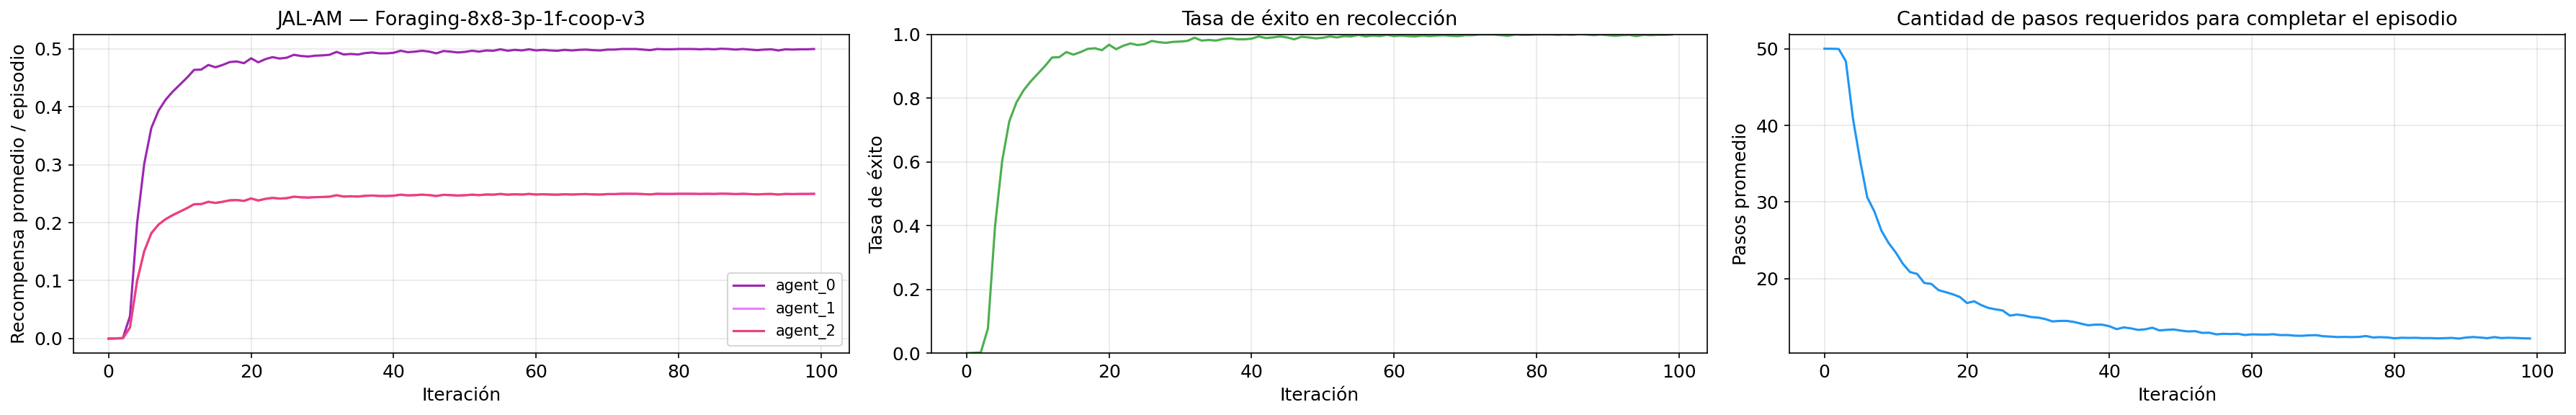

In [7]:
# ── JAL-AM — Config 3: Foraging-8x8-3p-1f-coop-v3 ────────────────────────────
config = configurations['3']
game_jalam_3 = Foraging(config=config['game'], seed=1)
agents_jalam_3 = {a: JointActionLearningAM(game=game_jalam_3, agent=a, **config['jalam'])
                  for a in game_jalam_3.agents}

print(f"=== JAL-AM — {config['game']} ===")
avg_jalam_3, success_jalam_3, steps_jalam_3 = train(game_jalam_3, agents_jalam_3, config['train_config'], progress=True)

plot_training(avg_jalam_3,
              title=f"JAL-AM — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1], JAL_AM_PALETTE[2]],
              save_path='figures/Foraging/jalam_config3_training.png',
              success_rates=success_jalam_3, avg_steps=steps_jalam_3)

for a in game_jalam_3.agents:
    agents_jalam_3[a].epsilon = 0.0
    agents_jalam_3[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_48060/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_48060/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


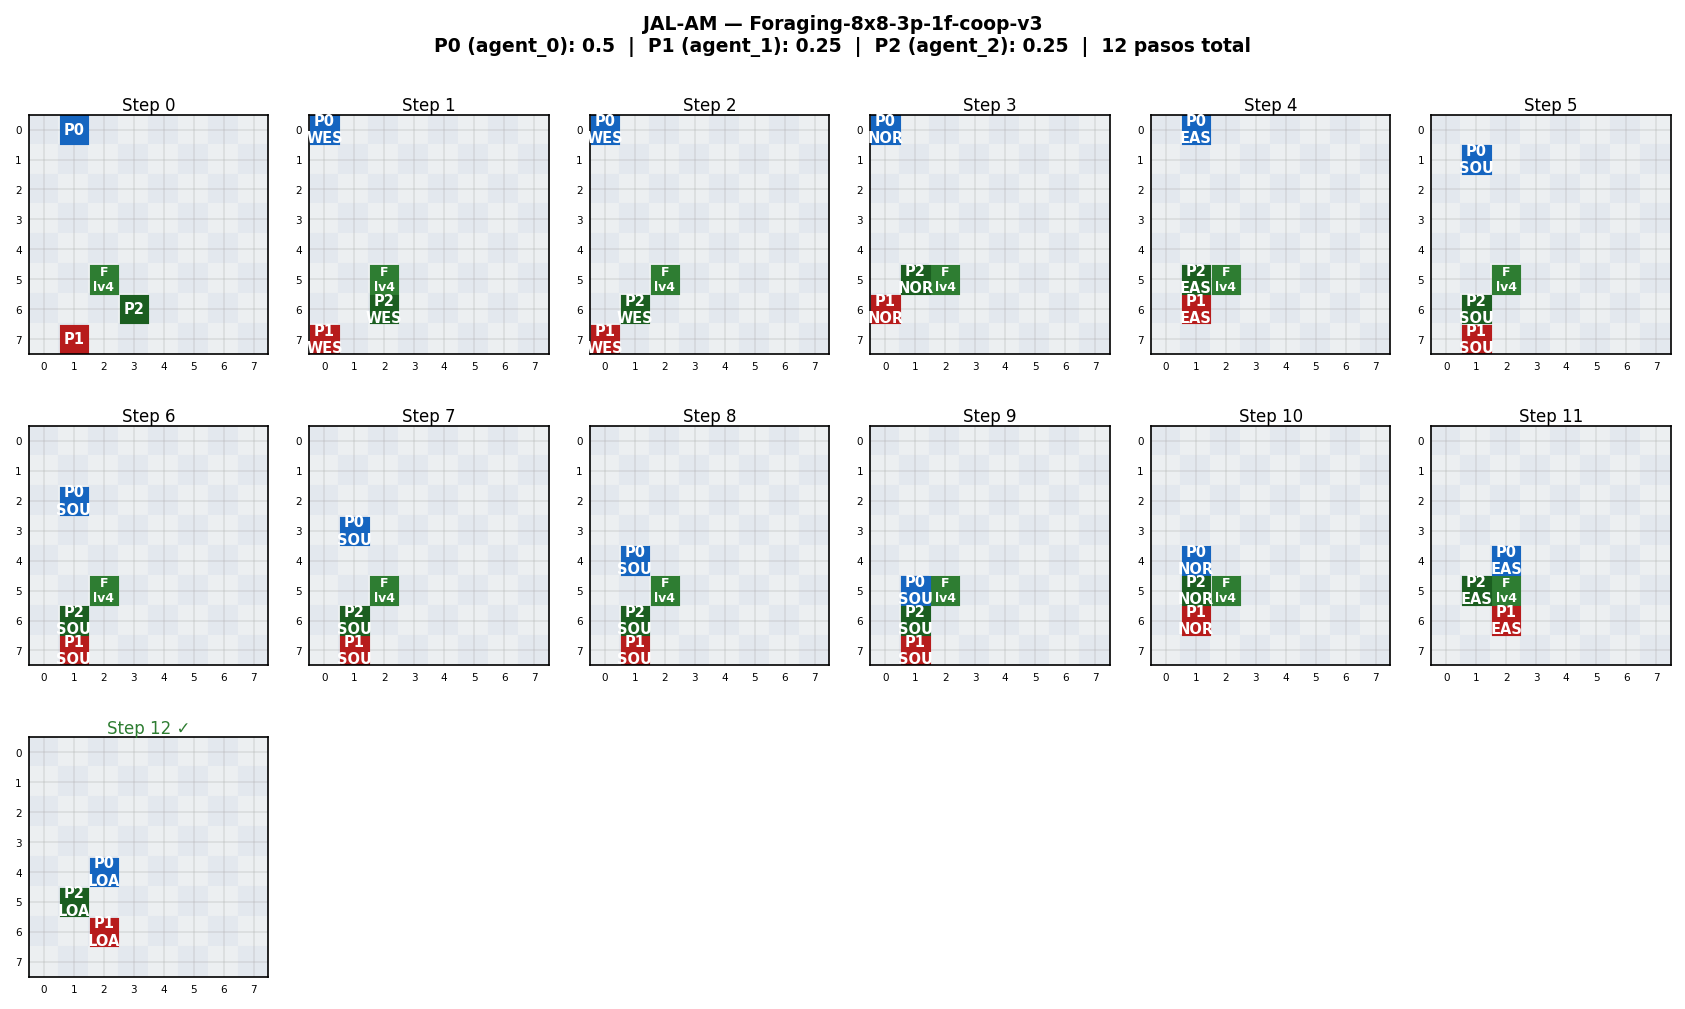

In [8]:
show_trained_game(game_jalam_3, agents_jalam_3, f'JAL-AM — {configurations["3"]["game"]}', save_path='figures/Foraging/jalam_config3_training.png')

#### Observaciones

En este experimento se evaluó una configuración cooperativa utilizando JAL-AM en `Foraging-8x8-3p-1f-coop-v3`.

Los resultados obtenidos son muy similares a los observados previamente con IQL en la misma configuración cooperativa. Las recompensas convergen extremadamente rápido durante las primeras iteraciones y luego permanecen prácticamente constantes y estables durante todo el entrenamiento.

Puede observarse que `agent_0` alcanza recompensas promedio cercanas a `0.5`, mientras que `agent_1` y `agent_2` convergen alrededor de `0.25`. Esto indica que todos los agentes participan de forma consistente en la recolección del recurso, aunque uno de ellos continúa obteniendo una proporción mayor de la recompensa total.

A diferencia de las configuraciones no cooperativas, aquí no aparece un agente completamente relegado o permanentemente alejado del objetivo. Por el contrario, todos los agentes convergen progresivamente hacia la comida y participan activamente del proceso de recolección.

La visualización del episodio entrenado muestra claramente este comportamiento cooperativo. Durante prácticamente todo el episodio los agentes se desplazan hacia la misma zona del mapa y permanecen agrupados cerca del recurso.

Además, el recurso posee:

- `food level = 4`

mientras que los agentes poseen niveles menores individualmente, por lo que resulta necesaria la cooperación de múltiples jugadores para ejecutar exitosamente la acción `LOAD`.

Las recompensas finales observadas fueron:

- `P0 = 0.5`
- `P1 = 0.25`
- `P2 = 0.25`

También puede observarse que el episodio requiere `12 pasos`, considerablemente más que en configuraciones no cooperativas. Esto resulta razonable, ya que los agentes necesitan coordinar movimientos y encontrarse simultáneamente cerca del recurso antes de poder recolectarlo.

En comparación con los experimentos anteriores, las diferencias entre IQL y JAL-AM dentro del entorno cooperativo no parecen demasiado significativas. Ambos algoritmos logran desarrollar rápidamente estrategias efectivas de cooperación y presentan comportamientos muy similares tanto en estabilidad como en distribución final de recompensas.

En conjunto, los resultados sugieren que el carácter cooperativo del entorno tiene un impacto mucho más importante en el comportamiento emergente de los agentes que el algoritmo específico utilizado para el aprendizaje.

#### JAL-AM × 2 + IQL × 1 — Config 3

P0 y P1 usan **JAL-AM**; P2 usa **IQL**. Modo cooperativo.

=== JAL-AM×2 + IQL×1 — Foraging-8x8-3p-1f-coop-v3 ===
Entrenamiento: 100 iteraciones × 1000 episodios
Estado inicial del episodio
  Comida: posición=(5, 2), nivel=4
  P0: posición=(0, 1), nivel=2
  P1: posición=(7, 1), nivel=1
  P2: posición=(6, 3), nivel=1

Iteración 10 (10000 episodios)
  agent_0: 0.4645
  agent_1: 0.2323
  agent_2: 0.2323
Iteración 20 (20000 episodios)
  agent_0: 0.4965
  agent_1: 0.2482
  agent_2: 0.2482
Iteración 30 (30000 episodios)
  agent_0: 0.4980
  agent_1: 0.2490
  agent_2: 0.2490
Iteración 40 (40000 episodios)
  agent_0: 0.5000
  agent_1: 0.2500
  agent_2: 0.2500
Iteración 50 (50000 episodios)
  agent_0: 0.5000
  agent_1: 0.2500
  agent_2: 0.2500
Iteración 60 (60000 episodios)
  agent_0: 0.5000
  agent_1: 0.2500
  agent_2: 0.2500
Iteración 70 (70000 episodios)
  agent_0: 0.5000
  agent_1: 0.2500
  agent_2: 0.2500
Iteración 80 (80000 episodios)
  agent_0: 0.5000
  agent_1: 0.2500
  agent_2: 0.2500
Iteración 90 (90000 episodios)
  agent_0: 0.5000
  agent_1: 0

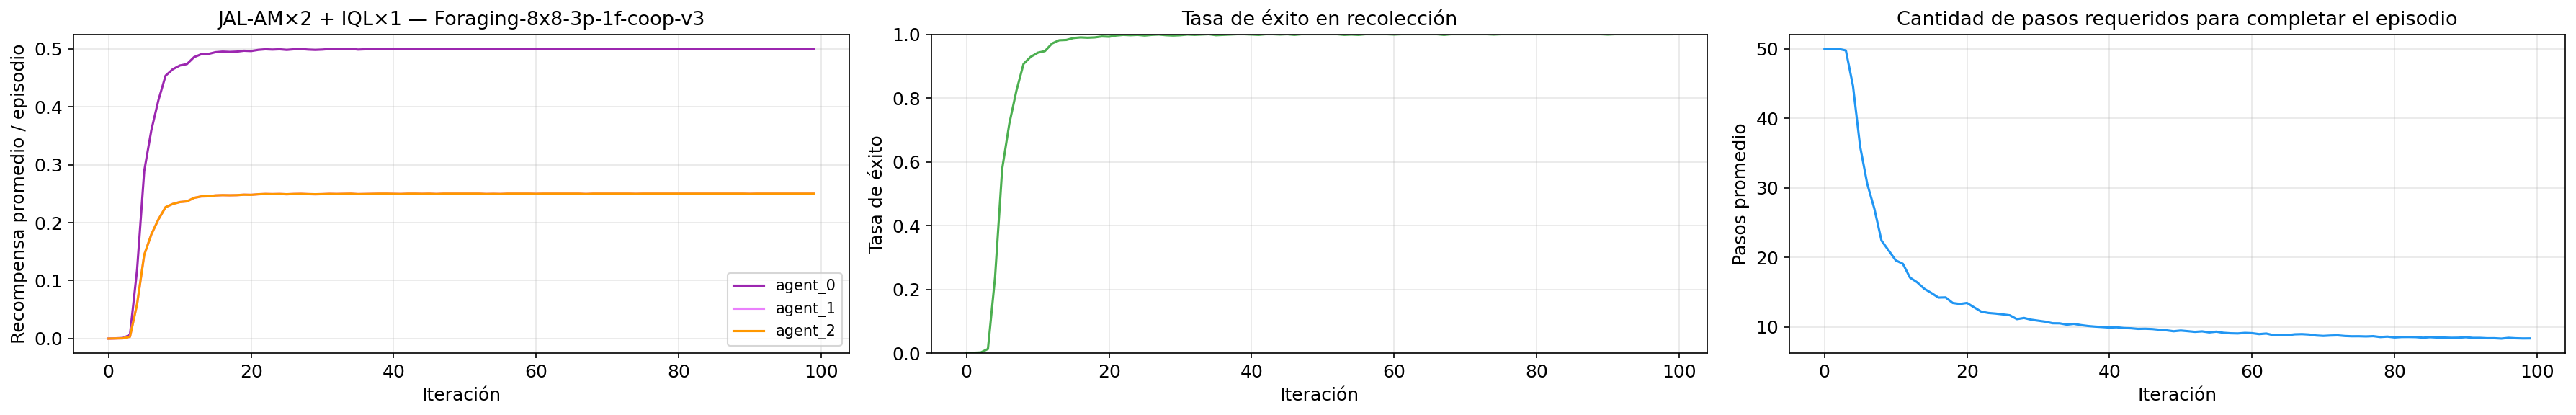

In [9]:
# ── JAL-AM×2 + IQL×1 — Config 3: Foraging-8x8-3p-1f-coop-v3 ─────────────────
config = configurations['3']
game_jalam2iql_3 = Foraging(config=config['game'], seed=1)
agents_jalam2iql_3 = {
    game_jalam2iql_3.agents[0]: JointActionLearningAM(game=game_jalam2iql_3, agent=game_jalam2iql_3.agents[0], **config['jalam']),
    game_jalam2iql_3.agents[1]: JointActionLearningAM(game=game_jalam2iql_3, agent=game_jalam2iql_3.agents[1], **config['jalam']),
    game_jalam2iql_3.agents[2]: IndependentQLearning(game=game_jalam2iql_3, agent=game_jalam2iql_3.agents[2], **config['iql']),
}

print(f"=== JAL-AM×2 + IQL×1 — {config['game']} ===")
avg_jalam2iql_3, success_jalam2iql_3, steps_jalam2iql_3 = train(game_jalam2iql_3, agents_jalam2iql_3, config['train_config'], progress=True)

plot_training(avg_jalam2iql_3,
              title=f"JAL-AM×2 + IQL×1 — {config['game']}",
              colors=[JAL_AM_PALETTE[0], JAL_AM_PALETTE[1], COLORS['IQL']],
              save_path='figures/Foraging/jalam2iql_config3_training.png',
              success_rates=success_jalam2iql_3, avg_steps=steps_jalam2iql_3)

for a in game_jalam2iql_3.agents:
    agents_jalam2iql_3[a].epsilon = 0.0
    agents_jalam2iql_3[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_48060/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_48060/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


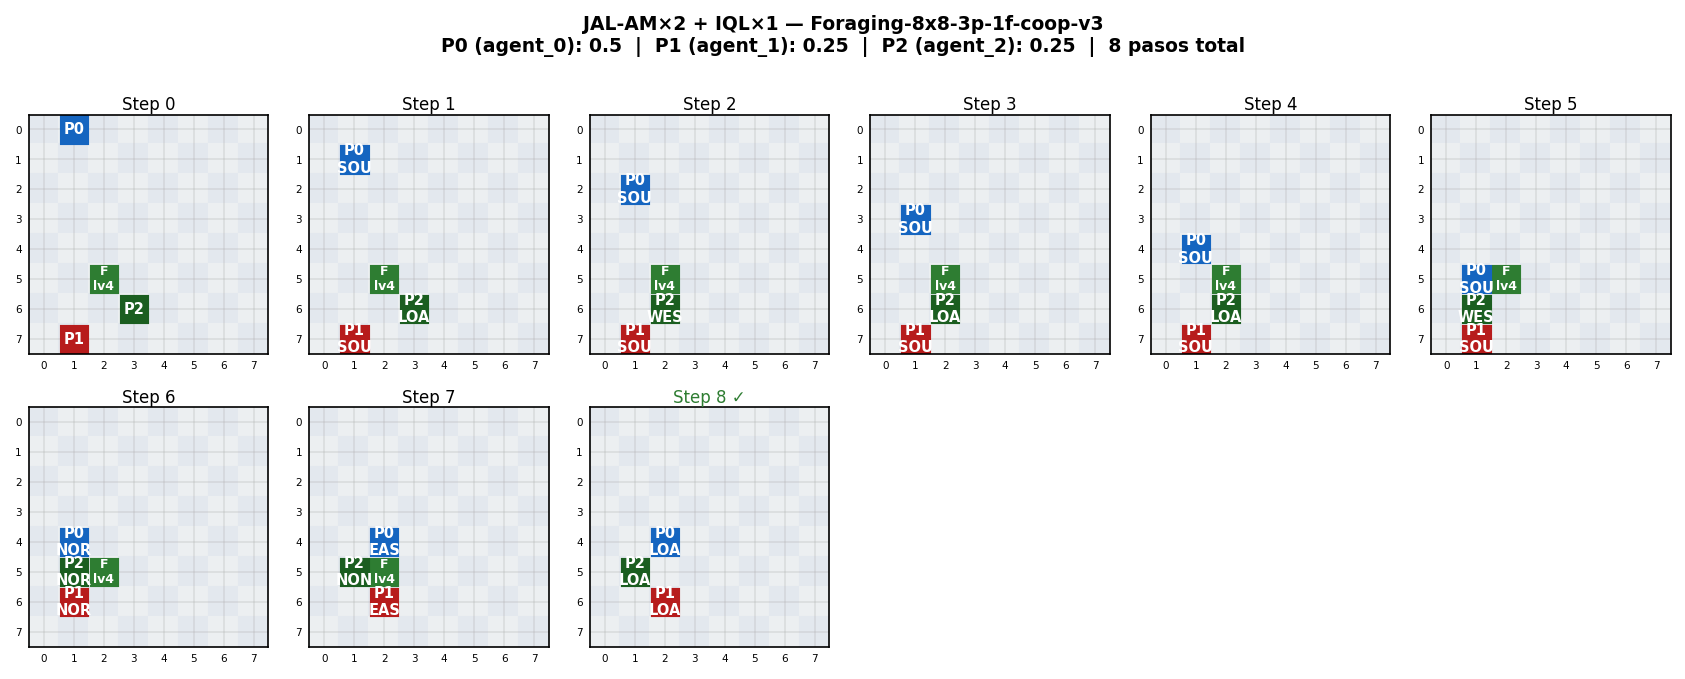

In [10]:
show_trained_game(game_jalam2iql_3, agents_jalam2iql_3, f'JAL-AM×2 + IQL×1 — {configurations["3"]["game"]}', save_path='figures/Foraging/jalam2iql_config3_game.png')

#### Observaciones

En este experimento se evaluó una configuración cooperativa mixta en `Foraging-8x8-3p-1f-coop-v3`, donde `P0` y `P1` utilizan JAL-AM mientras que `P2` utiliza IQL.

Los resultados muestran nuevamente un comportamiento altamente cooperativo y estable. Las recompensas convergen muy rápidamente durante las primeras iteraciones y luego permanecen prácticamente constantes durante todo el entrenamiento.

Puede observarse que:

- `agent_0` converge a recompensas cercanas a `0.5`
- `agent_1` y `agent_2` convergen alrededor de `0.25`

Este patrón es similar al observado previamente tanto en IQL cooperativo como en JAL-AM cooperativo puro. Esto sugiere que, dentro de este entorno cooperativo, la estructura del problema tiene mayor influencia sobre el comportamiento emergente que el algoritmo específico utilizado.

La visualización del episodio entrenado muestra claramente cómo los agentes convergen progresivamente hacia la comida y coordinan sus movimientos cerca del recurso.

Además:

- `food level = 4`

por lo que resulta necesaria la cooperación de múltiples agentes para poder ejecutar exitosamente la acción `LOAD`.

Las recompensas finales observadas fueron:

- `P0 = 0.5`
- `P1 = 0.25`
- `P2 = 0.25`

Puede observarse también que los tres agentes participan activamente del episodio y terminan relativamente cerca de la comida durante las últimas etapas del juego. A diferencia de los entornos no cooperativos, aquí no aparece un agente completamente relegado o permanentemente alejado del recurso.

Otro aspecto interesante es que el episodio termina en únicamente `8 pasos`, menos que en experimentos cooperativos anteriores (`12 pasos`). Esto sugiere que los agentes lograron aprender trayectorias más eficientes hacia el objetivo compartido.

En comparación con configuraciones no cooperativas, aquí desaparecen casi completamente los comportamientos competitivos y las grandes diferencias de recompensa entre agentes. El entorno incentiva naturalmente la coordinación y los agentes desarrollan rápidamente estrategias colectivas efectivas.

En conjunto, los resultados muestran que combinar JAL-AM e IQL dentro de un entorno cooperativo sigue produciendo comportamientos altamente coordinados, estables y eficientes, muy similares a los observados cuando todos los agentes utilizan el mismo algoritmo.

#### IQL × 2 + JAL-AM × 1 — Config 3

P0 y P1 usan **IQL**; P2 usa **JAL-AM**. Modo cooperativo.

=== IQL×2 + JAL-AM×1 — Foraging-8x8-3p-1f-coop-v3 ===
Entrenamiento: 100 iteraciones × 1000 episodios
Estado inicial del episodio
  Comida: posición=(5, 2), nivel=4
  P0: posición=(0, 1), nivel=2
  P1: posición=(7, 1), nivel=1
  P2: posición=(6, 3), nivel=1

Iteración 10 (10000 episodios)
  agent_0: 0.4660
  agent_1: 0.2330
  agent_2: 0.2330
Iteración 20 (20000 episodios)
  agent_0: 0.4950
  agent_1: 0.2475
  agent_2: 0.2475
Iteración 30 (30000 episodios)
  agent_0: 0.5000
  agent_1: 0.2500
  agent_2: 0.2500
Iteración 40 (40000 episodios)
  agent_0: 0.5000
  agent_1: 0.2500
  agent_2: 0.2500
Iteración 50 (50000 episodios)
  agent_0: 0.5000
  agent_1: 0.2500
  agent_2: 0.2500
Iteración 60 (60000 episodios)
  agent_0: 0.5000
  agent_1: 0.2500
  agent_2: 0.2500
Iteración 70 (70000 episodios)
  agent_0: 0.5000
  agent_1: 0.2500
  agent_2: 0.2500
Iteración 80 (80000 episodios)
  agent_0: 0.5000
  agent_1: 0.2500
  agent_2: 0.2500
Iteración 90 (90000 episodios)
  agent_0: 0.5000
  agent_1: 0

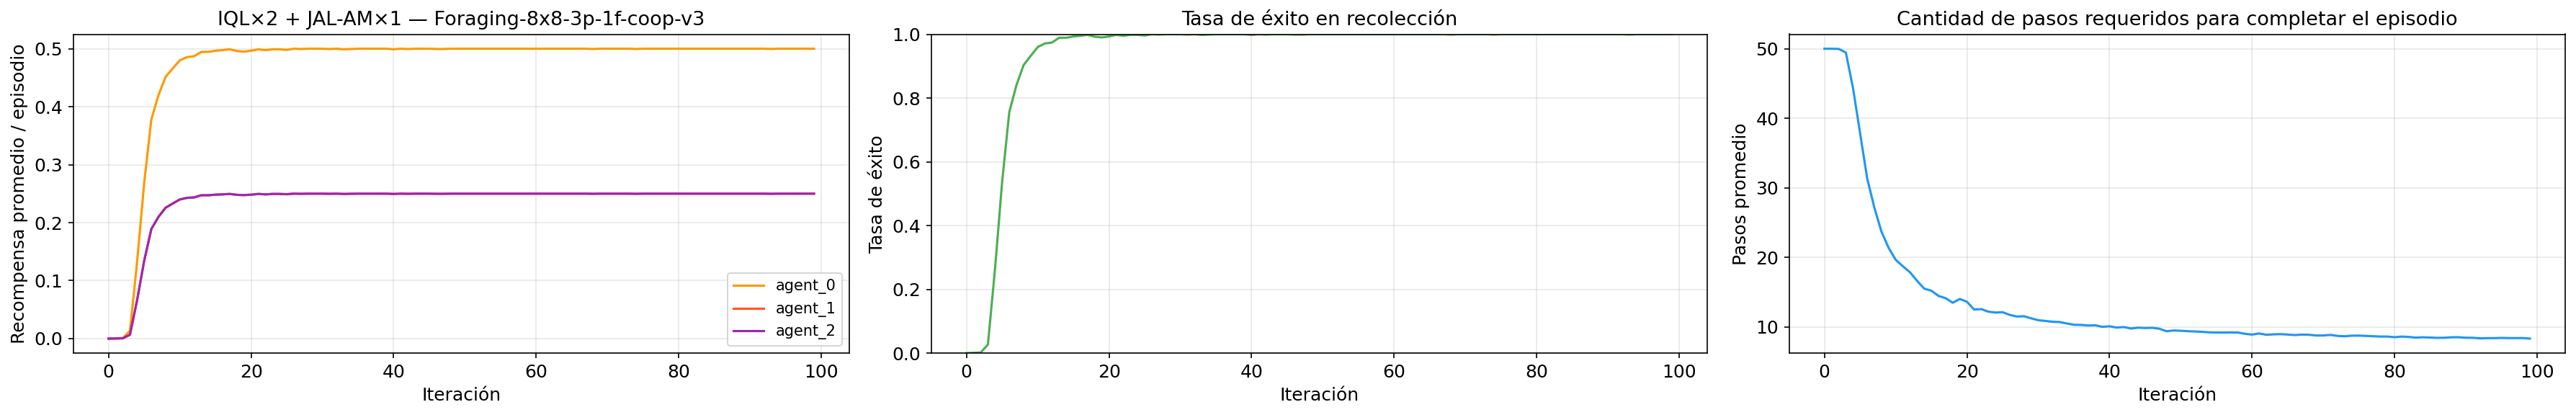

In [11]:
# ── IQL×2 + JAL-AM×1 — Config 3: Foraging-8x8-3p-1f-coop-v3 ─────────────────
config = configurations['3']
game_iql2jalam_3 = Foraging(config=config['game'], seed=1)
agents_iql2jalam_3 = {
    game_iql2jalam_3.agents[0]: IndependentQLearning(game=game_iql2jalam_3, agent=game_iql2jalam_3.agents[0], **config['iql']),
    game_iql2jalam_3.agents[1]: IndependentQLearning(game=game_iql2jalam_3, agent=game_iql2jalam_3.agents[1], **config['iql']),
    game_iql2jalam_3.agents[2]: JointActionLearningAM(game=game_iql2jalam_3, agent=game_iql2jalam_3.agents[2], **config['jalam']),
}

print(f"=== IQL×2 + JAL-AM×1 — {config['game']} ===")
avg_iql2jalam_3, success_iql2jalam_3, steps_iql2jalam_3 = train(game_iql2jalam_3, agents_iql2jalam_3, config['train_config'], progress=True)

plot_training(avg_iql2jalam_3,
              title=f"IQL×2 + JAL-AM×1 — {config['game']}",
              colors=[COLORS['IQL'], '#FF5722', JAL_AM_PALETTE[0]],
              save_path='figures/Foraging/iql2jalam_config3_training.png',
              success_rates=success_iql2jalam_3, avg_steps=steps_iql2jalam_3)

for a in game_iql2jalam_3.agents:
    agents_iql2jalam_3[a].epsilon = 0.0
    agents_iql2jalam_3[a].alpha   = 0.0

/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_48060/791533146.py:13: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((c - 0.44, r - 0.44), 0.88, 0.88,
/var/folders/s2/p5yczv2s3gv32c5qs90gpnh00000gn/T/ipykernel_48060/791533146.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((pc - 0.44, pr - 0.44), 0.88, 0.88,


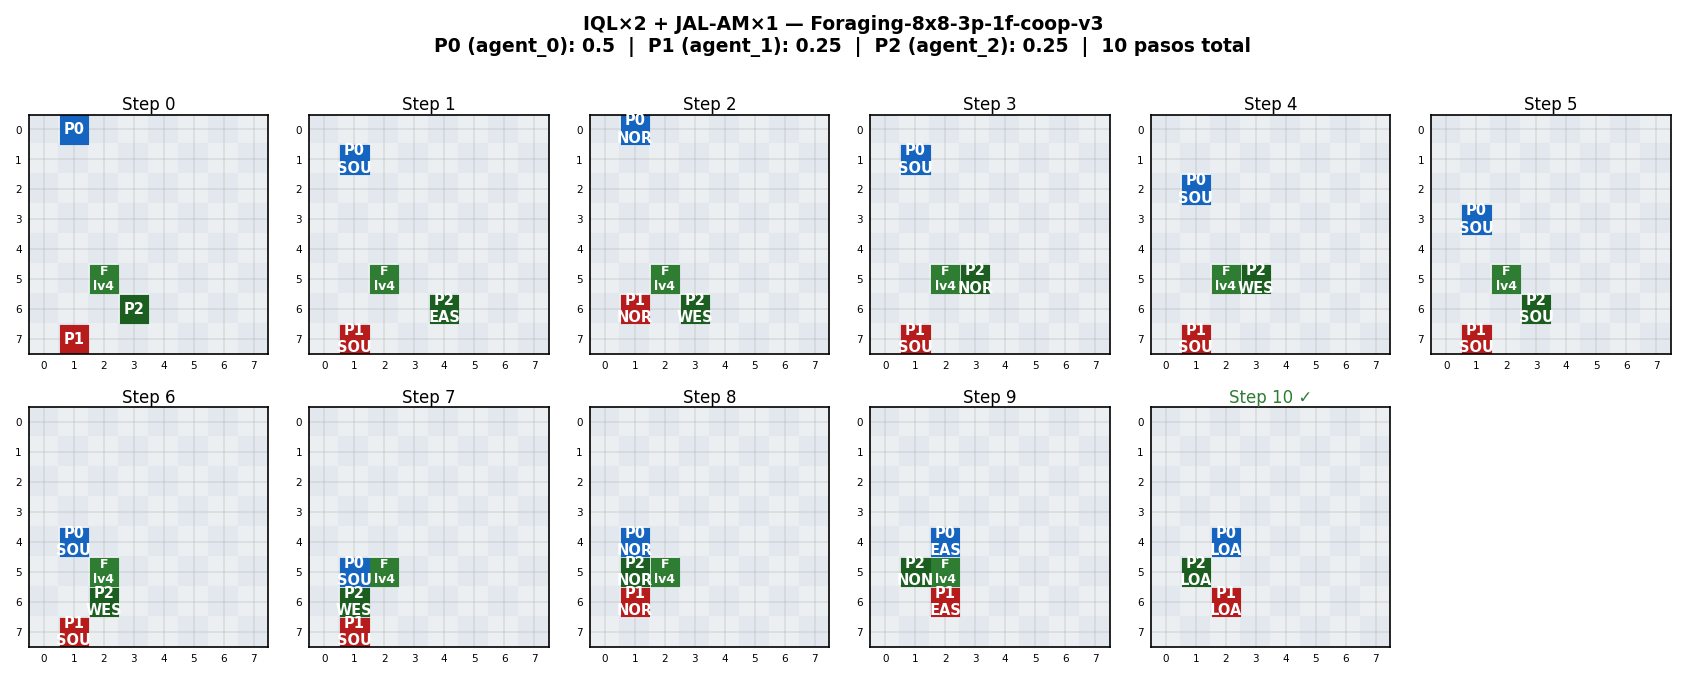

In [12]:
show_trained_game(game_iql2jalam_3, agents_iql2jalam_3, f'IQL×2 + JAL-AM×1 — {configurations["3"]["game"]}',  save_path='figures/Foraging/iql2jalam_config3_game.png')

#### Observaciones

En este experimento se evaluó una configuración cooperativa mixta en `Foraging-8x8-3p-1f-coop-v3`, donde `P0` y `P1` utilizan IQL mientras que `P2` utiliza JAL-AM.

Los resultados muestran nuevamente una convergencia extremadamente rápida y estable. Durante las primeras iteraciones las recompensas aumentan abruptamente y luego permanecen prácticamente constantes durante el resto del entrenamiento.

Puede observarse que:

- `agent_0` converge a recompensas cercanas a `0.5`
- `agent_1` y `agent_2` convergen alrededor de `0.25`

Este patrón vuelve a ser muy similar al observado en las demás configuraciones cooperativas, independientemente de la combinación de algoritmos utilizada. Esto refuerza la idea de que el entorno cooperativo domina el comportamiento emergente de los agentes más que el algoritmo específico de aprendizaje.

La visualización del episodio entrenado muestra nuevamente una coordinación efectiva entre los jugadores. Los agentes convergen progresivamente hacia la comida y permanecen relativamente agrupados cerca del recurso durante las últimas etapas del episodio.

Además:

- `food level = 4`

por lo que resulta necesaria la participación de múltiples agentes para ejecutar exitosamente la acción `LOAD`.

Las recompensas finales observadas fueron:

- `P0 = 0.5`
- `P1 = 0.25`
- `P2 = 0.25`

También puede observarse que el episodio termina en `10 pasos`, nuevamente menos que en algunos escenarios cooperativos anteriores. Esto sugiere que los agentes lograron aprender trayectorias eficientes y una coordinación relativamente rápida hacia el objetivo compartido.

A diferencia de los entornos no cooperativos, aquí no aparecen agentes completamente excluidos de la recompensa. Todos los agentes participan activamente del episodio y terminan colaborando en la recolección del recurso.

Comparando este experimento con:

- IQL cooperativo puro,
- JAL-AM cooperativo puro,
- JAL-AM×2 + IQL×1,

las diferencias observadas son mínimas. En todos los casos emerge rápidamente un comportamiento cooperativo estable, con distribuciones de recompensa muy similares y trayectorias eficientes hacia la comida.

En conjunto, los resultados sugieren que, dentro de entornos explícitamente cooperativos, tanto IQL como JAL-AM son capaces de aprender estrategias coordinadas efectivas, y que la mezcla de algoritmos no altera significativamente el comportamiento global del sistema.

Los experimentos realizados sobre distintos entornos `Foraging` permitieron analizar el comportamiento de agentes multiagente utilizando IQL y JAL-AM en escenarios cooperativos y no cooperativos.

En los escenarios no cooperativos se observaron comportamientos desbalanceados, donde algunos agentes obtenían consistentemente mayores recompensas mientras otros quedaban relegados. Además, apareció repetidamente una relación entre la posición de los agentes y sus recompensas: los agentes más alejados de la comida tendían a obtener peores resultados. Esto sugiere que pequeñas ventajas iniciales de posicionamiento o exploración pueden amplificarse progresivamente durante el entrenamiento.

IQL logró aprender trayectorias eficientes y generar cooperación parcial emergente, aunque mostró mayor sensibilidad a las posiciones iniciales y una distribución de recompensas más inestable. Esto coincide con lo esperado teóricamente, ya que cada agente aprende independientemente sin modelar explícitamente a los demás.

Por otro lado, JAL-AM presentó comportamientos generalmente más estables y coordinados. El modelado explícito de otros agentes permitió reducir parcialmente el problema de non-stationarity y mejorar la coordinación dentro del entorno.

En los escenarios cooperativos las diferencias entre algoritmos se redujeron considerablemente. Tanto IQL como JAL-AM lograron aprender estrategias altamente coordinadas, con convergencia rápida, recompensas estables y participación activa de todos los agentes en la recolección de la comida.

Además, un resultado particularmente interesante fue que las configuraciones mixtas (`IQL + JAL-AM`) parecieron converger tan rápido o incluso ligeramente más rápido que algunas configuraciones homogéneas. En varios experimentos, los agentes lograron estabilizar las recompensas en menos iteraciones y resolver el entorno utilizando menos pasos totales.

Una posible explicación es que los agentes JAL-AM aportan mayor estabilidad y coordinación gracias al modelado explícito del comportamiento de otros jugadores, mientras que los agentes IQL mantienen comportamientos más exploratorios. La combinación de ambos enfoques podría generar dinámicas de aprendizaje complementarias dentro de entornos cooperativos.

Sin embargo, las diferencias observadas son relativamente pequeñas y sería necesario realizar más experimentos utilizando una mayor cantidad de seeds para confirmar esta tendencia con mayor confianza.

En conjunto, los resultados muestran que:

- la estructura del entorno tiene un impacto muy fuerte sobre el comportamiento emergente,
- la cooperación puede surgir incluso en escenarios parcialmente competitivos,
- y modelar explícitamente a otros agentes, como hace JAL-AM, ayuda a obtener comportamientos más estables y coordinados.